In [1]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [2]:
data_name = 'Kang'
yaml_name = 'kang'
methods = ['SCDISENTANGLE', 'CPA', 'SCDISINFACT', 'SCGEN', 'BIOLORD']
cov_key = 'cell_type'
cond_key = 'condition'
control_name = 'control'
stim_name = 'stimulated'
degs_key = 'rank_genes_groups_condition'
ood_covs = ['B', 'NK', 'CD4 T', 'CD8 T', 'T', 'CD14 Mono', 'CD16 Mono', 'DC']

# Compute Metrics

In [ ]:
import compute_metrics as cm

In [ ]:
cm.compute_metrics(
    data_name=data_name,
    yaml_name=yaml_name,
    methods=methods,
    cov_key=cov_key,
    cond_key=cond_key,
    control_name=control_name,
    stim_name=stim_name,
    degs_key=degs_key,
    ood_covs=ood_covs
)

In [ ]:
cm.compute_metrics_baselines(
    data_name=data_name,
    methods=['Pert Mean', 'Ctrl Mean'],
    cov_key=cov_key,
    cond_key=cond_key,
    control_name=control_name,
    stim_name=stim_name,
    degs_key=degs_key,
    ood_covs=ood_covs
)

# Export results

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import hygeia.utils.hplots as hp
import metrics_tools as mt

In [4]:
data_name = 'Kang'
cov_key = 'cell_type'
cond_key = 'condition'
stim_name = 'stimulated'
control_name = 'control'
covs = ['B', 'NK', 'CD4 T', 'CD8 T', 'T', 'CD14 Mono', 'CD16 Mono', 'DC']

all_results = []
for cov in covs:
    for i in range(1, 11):
        all_results.append(f'{cov}_{i}')

In [5]:
base_path = f'results/{data_name}'

In [6]:
os.makedirs(f'{FIG_ROOT}/{data_name}/Benchmarks/', exist_ok=True)

Using 80 perturbation


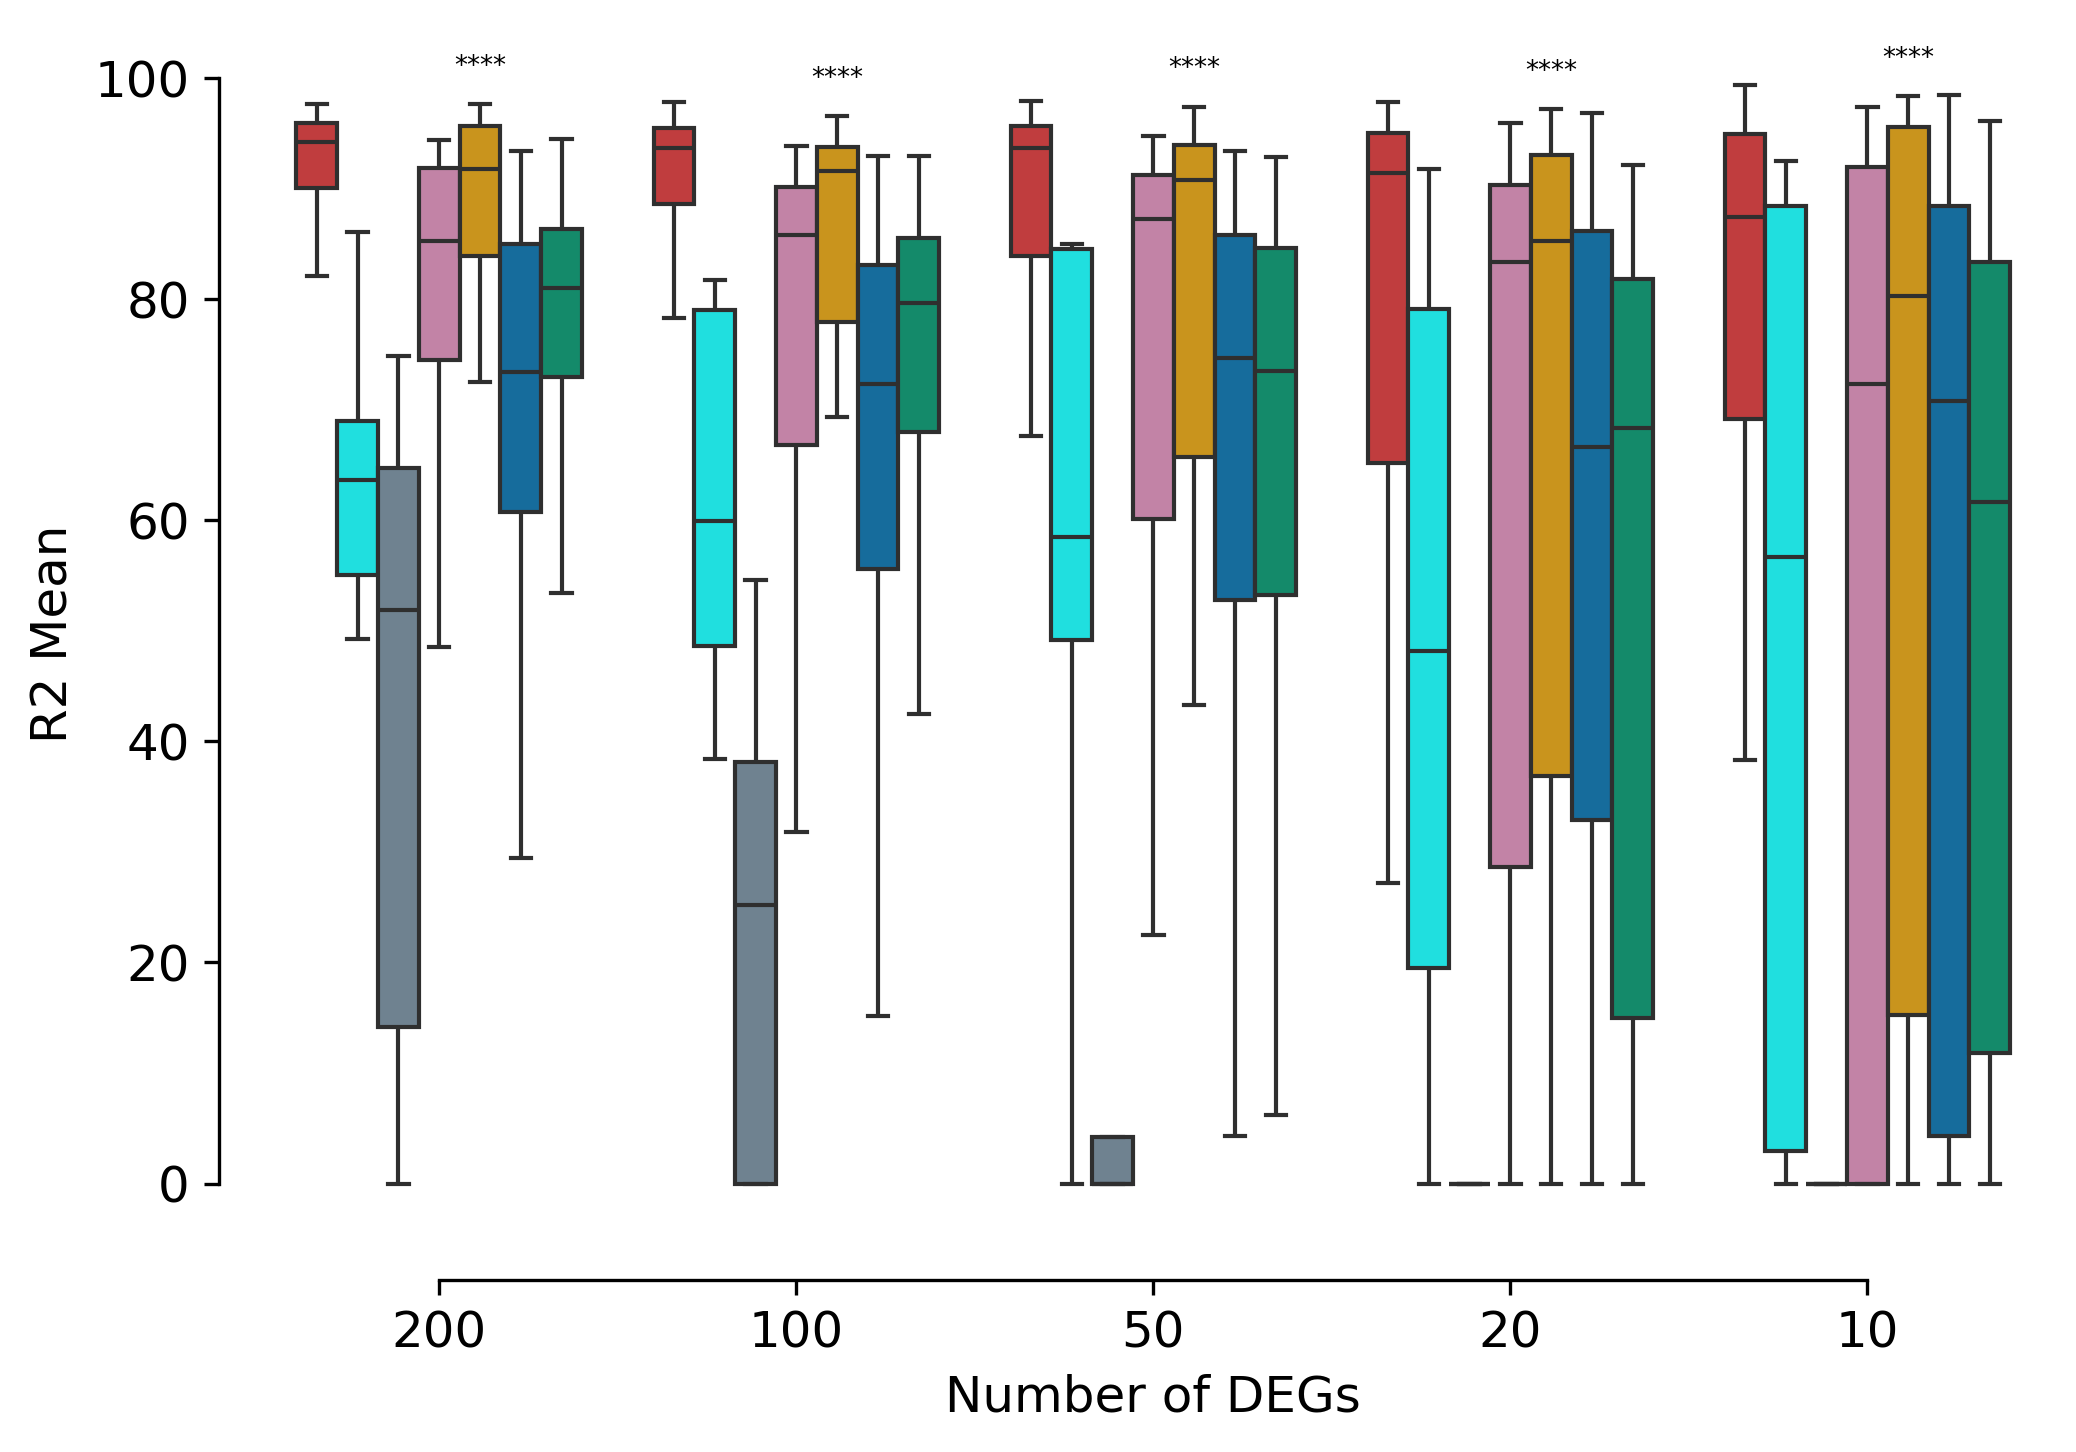

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


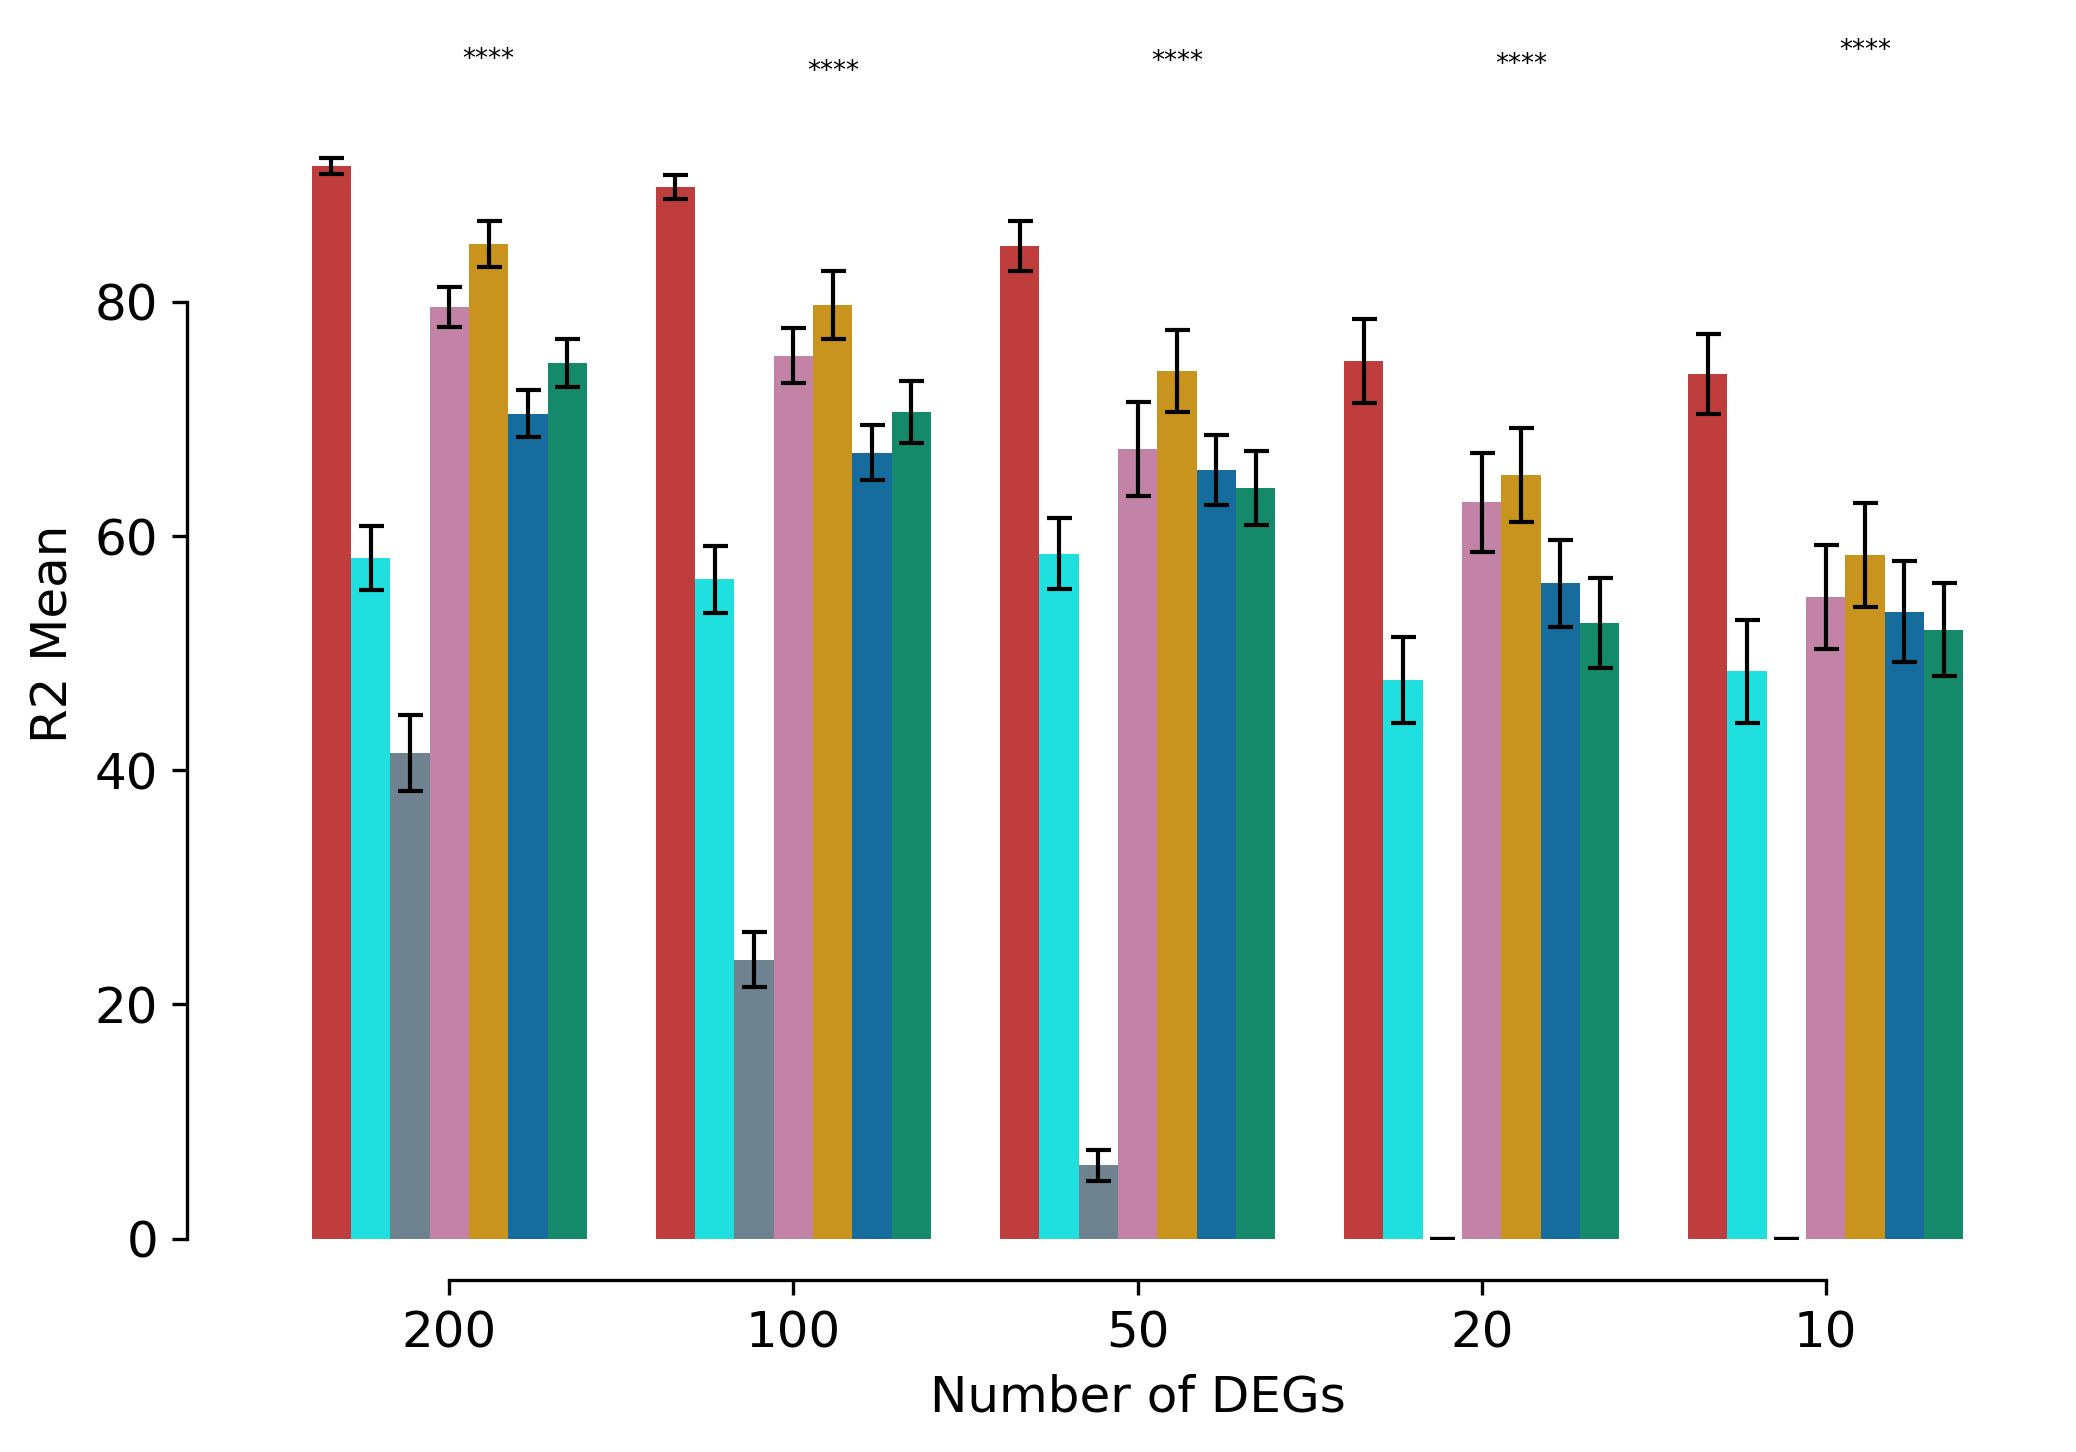

Using 80 perturbation


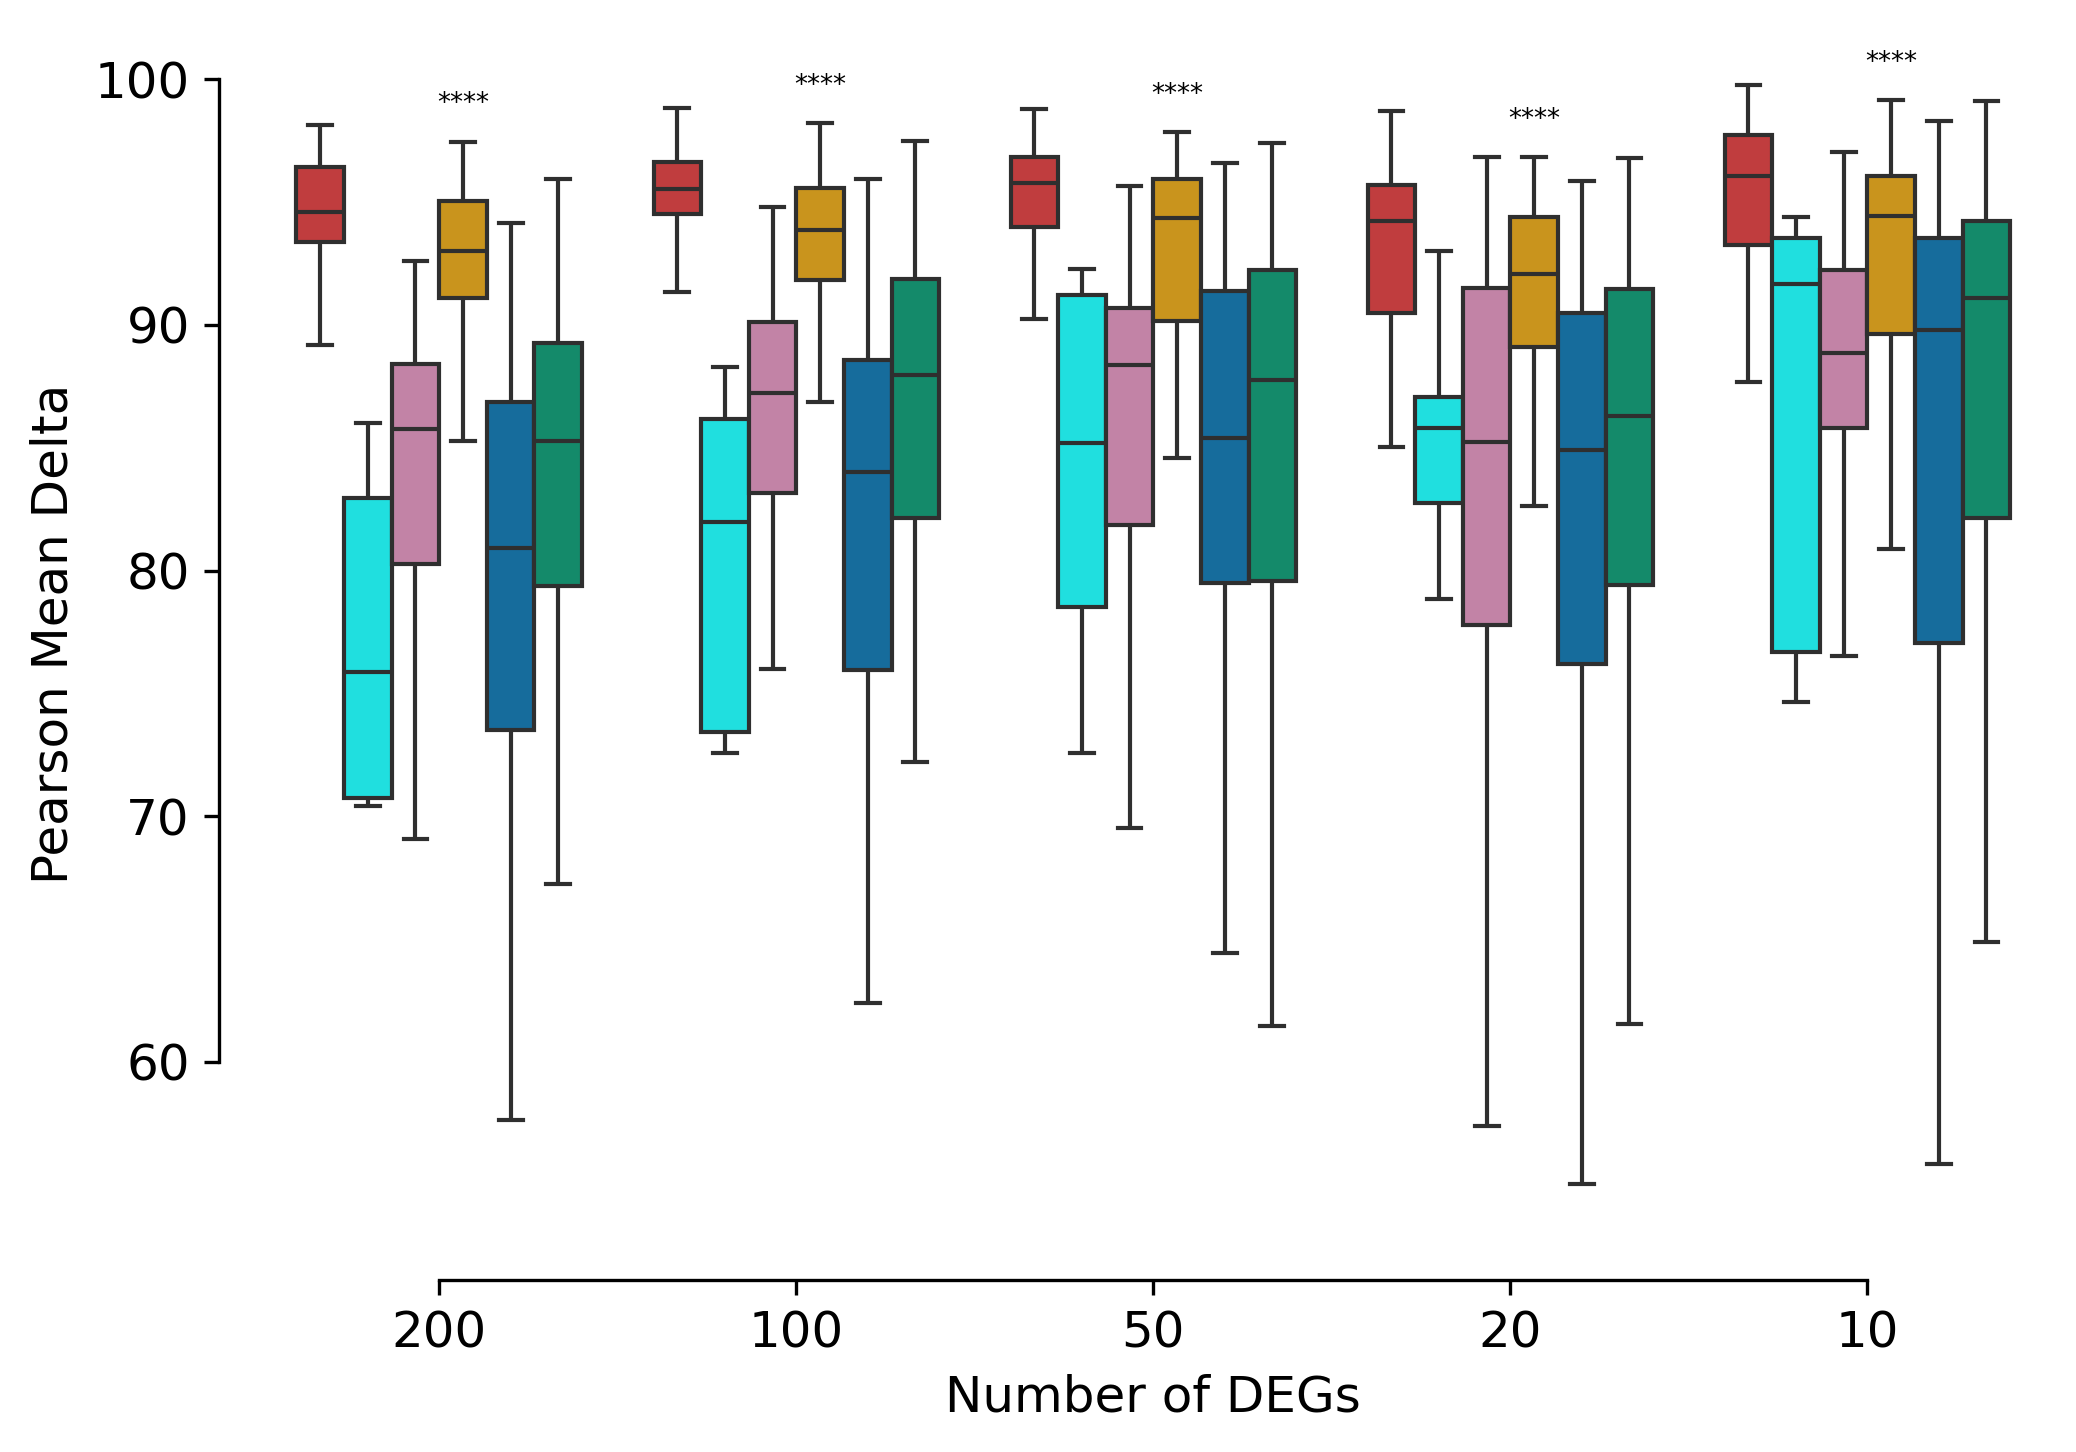

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


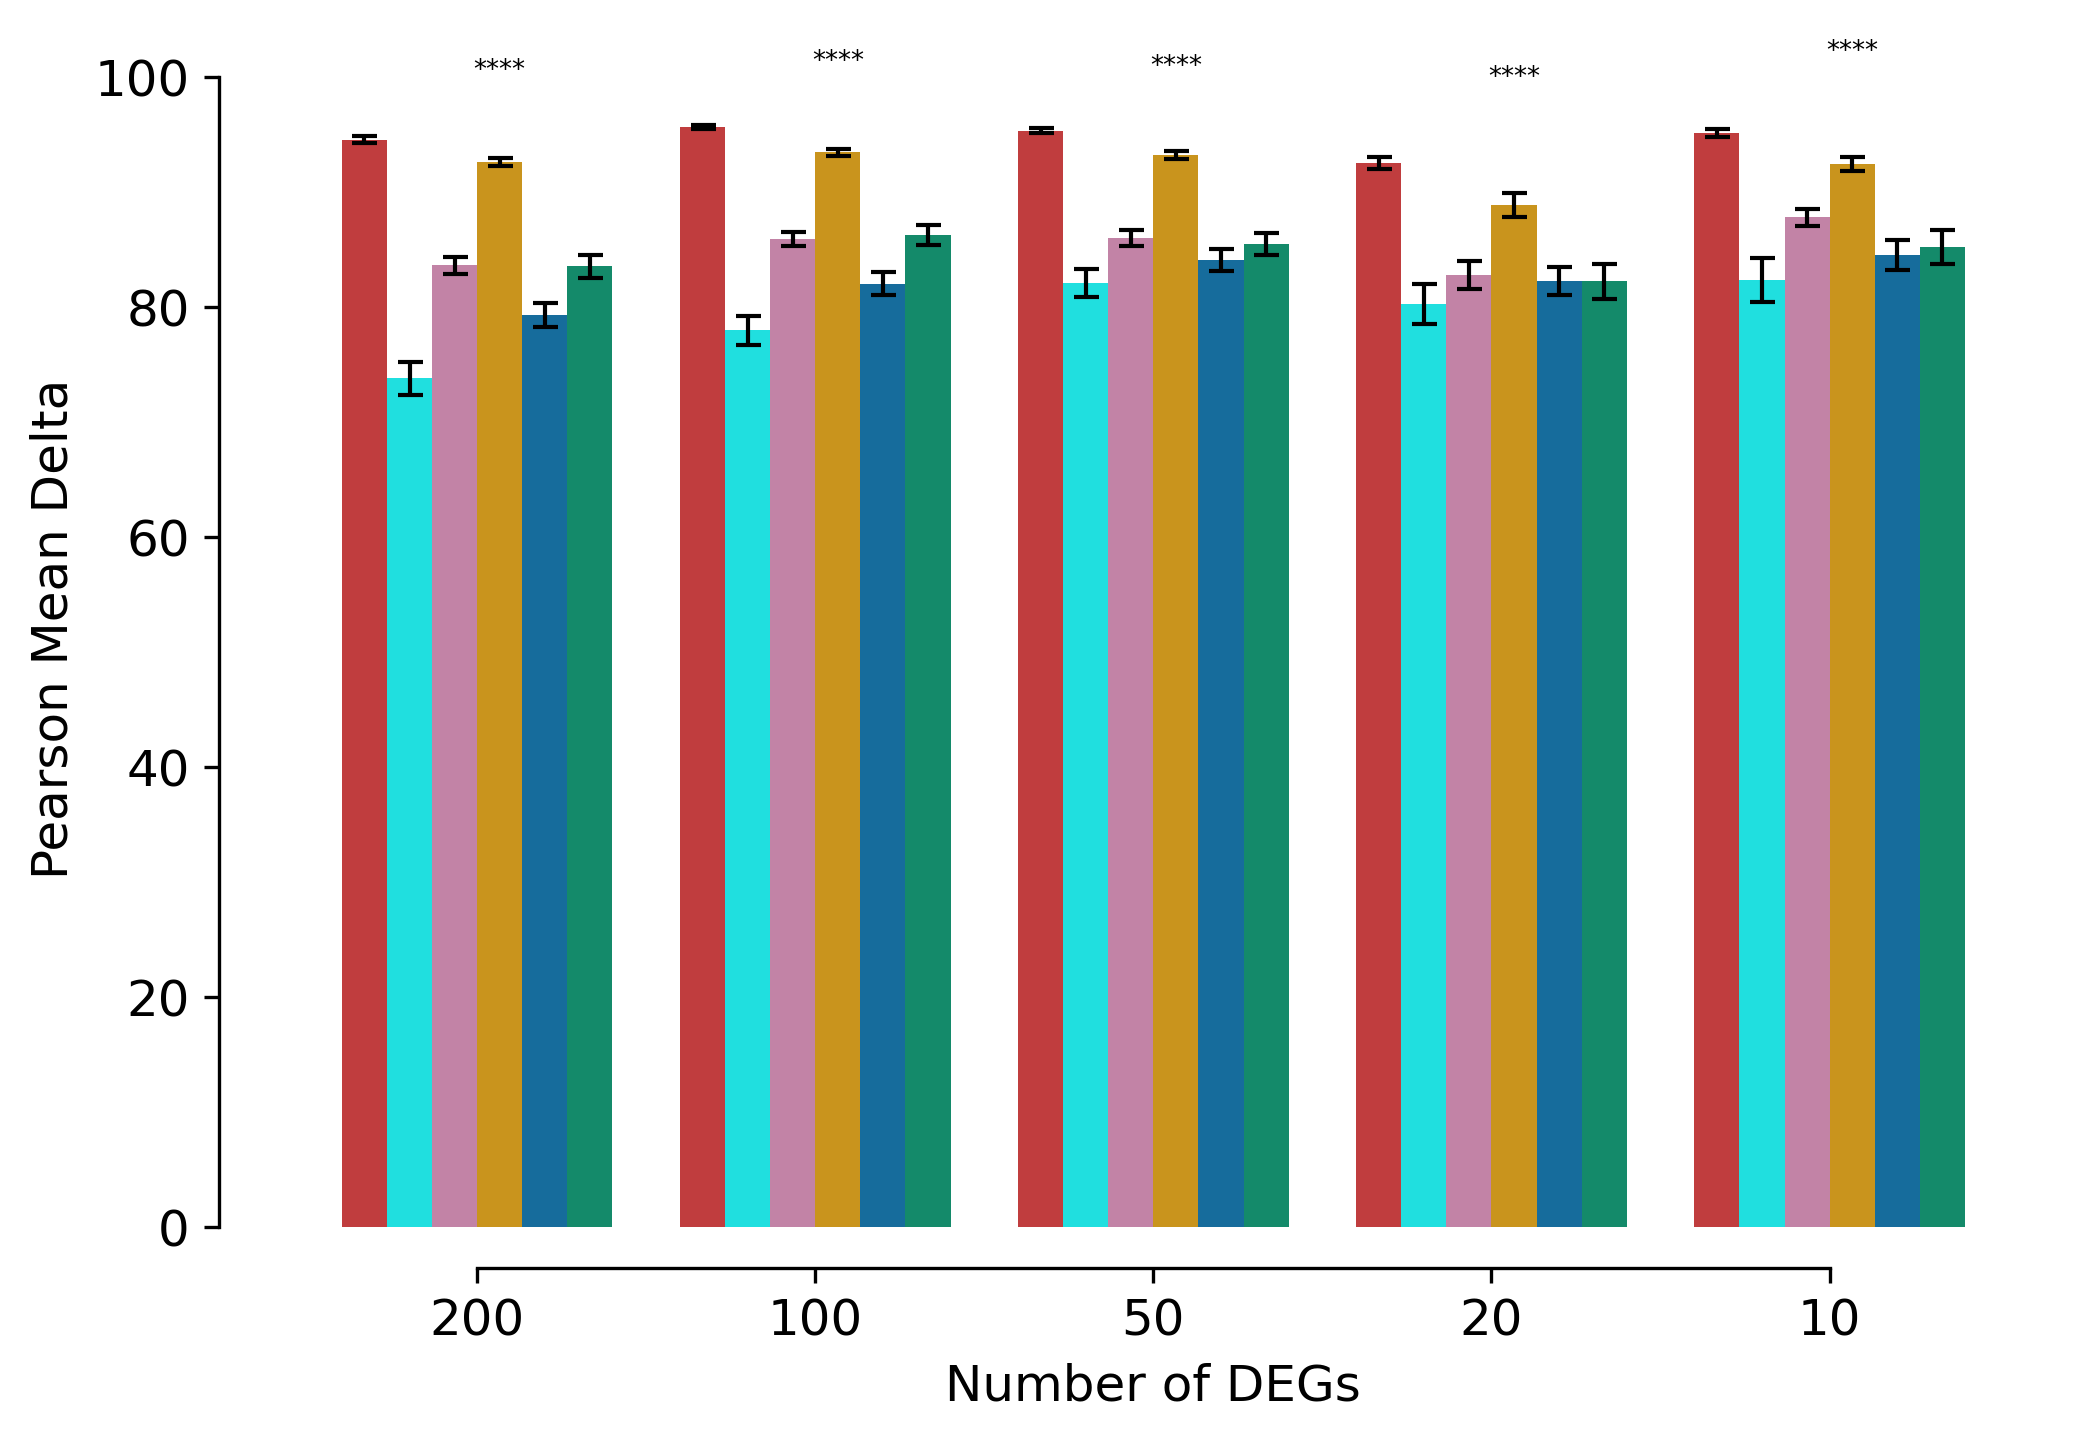

Using 80 perturbation


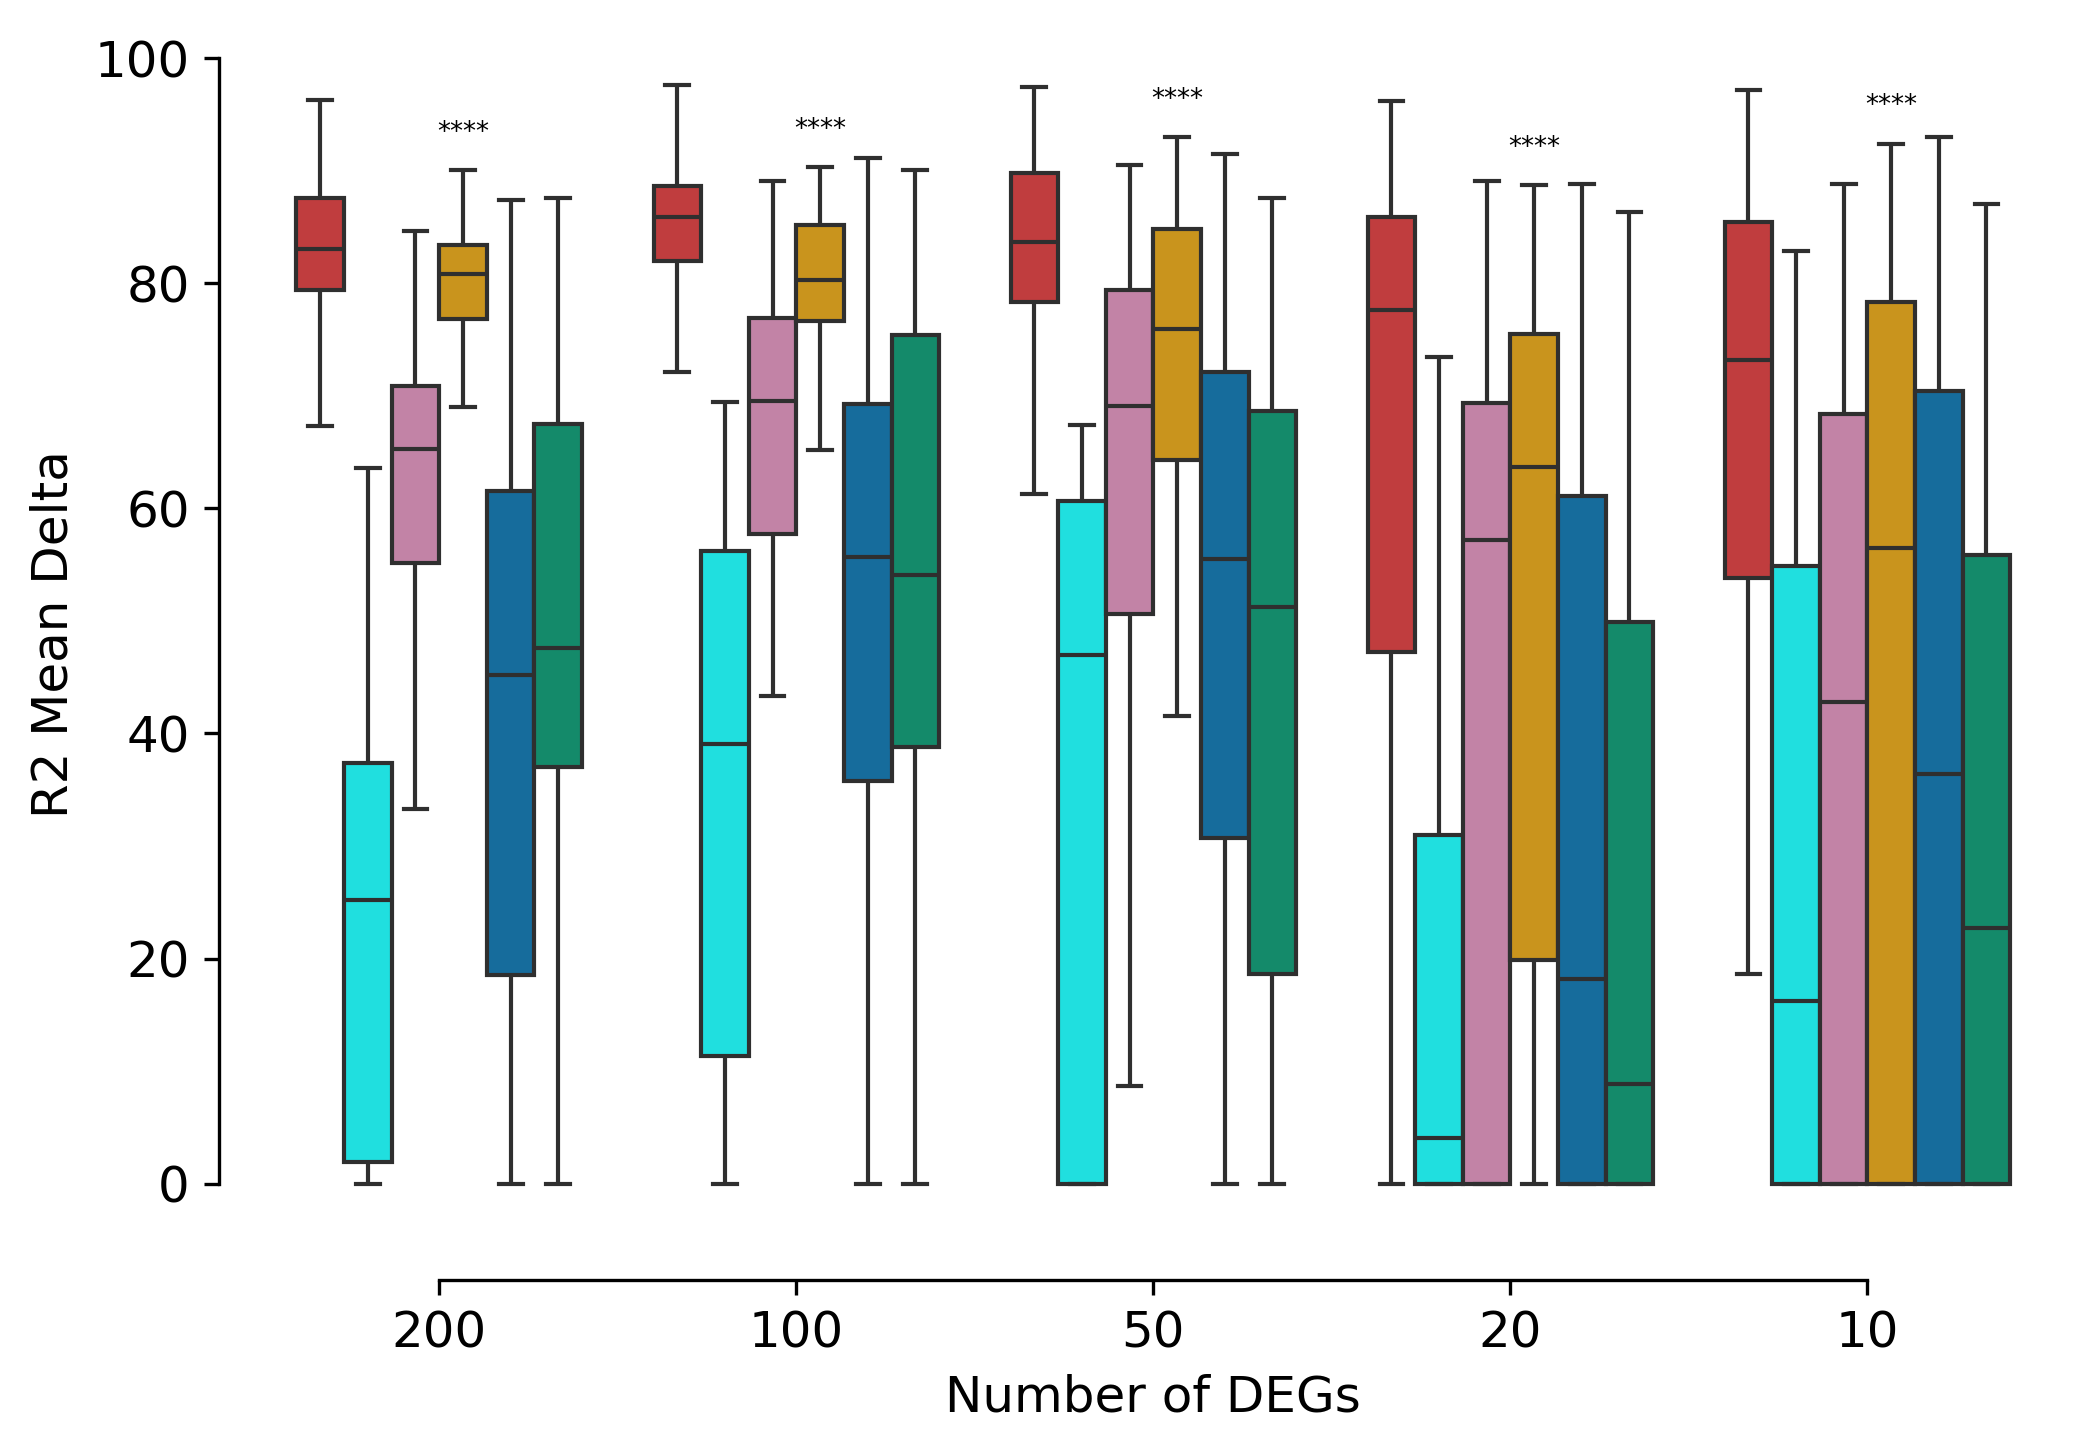

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


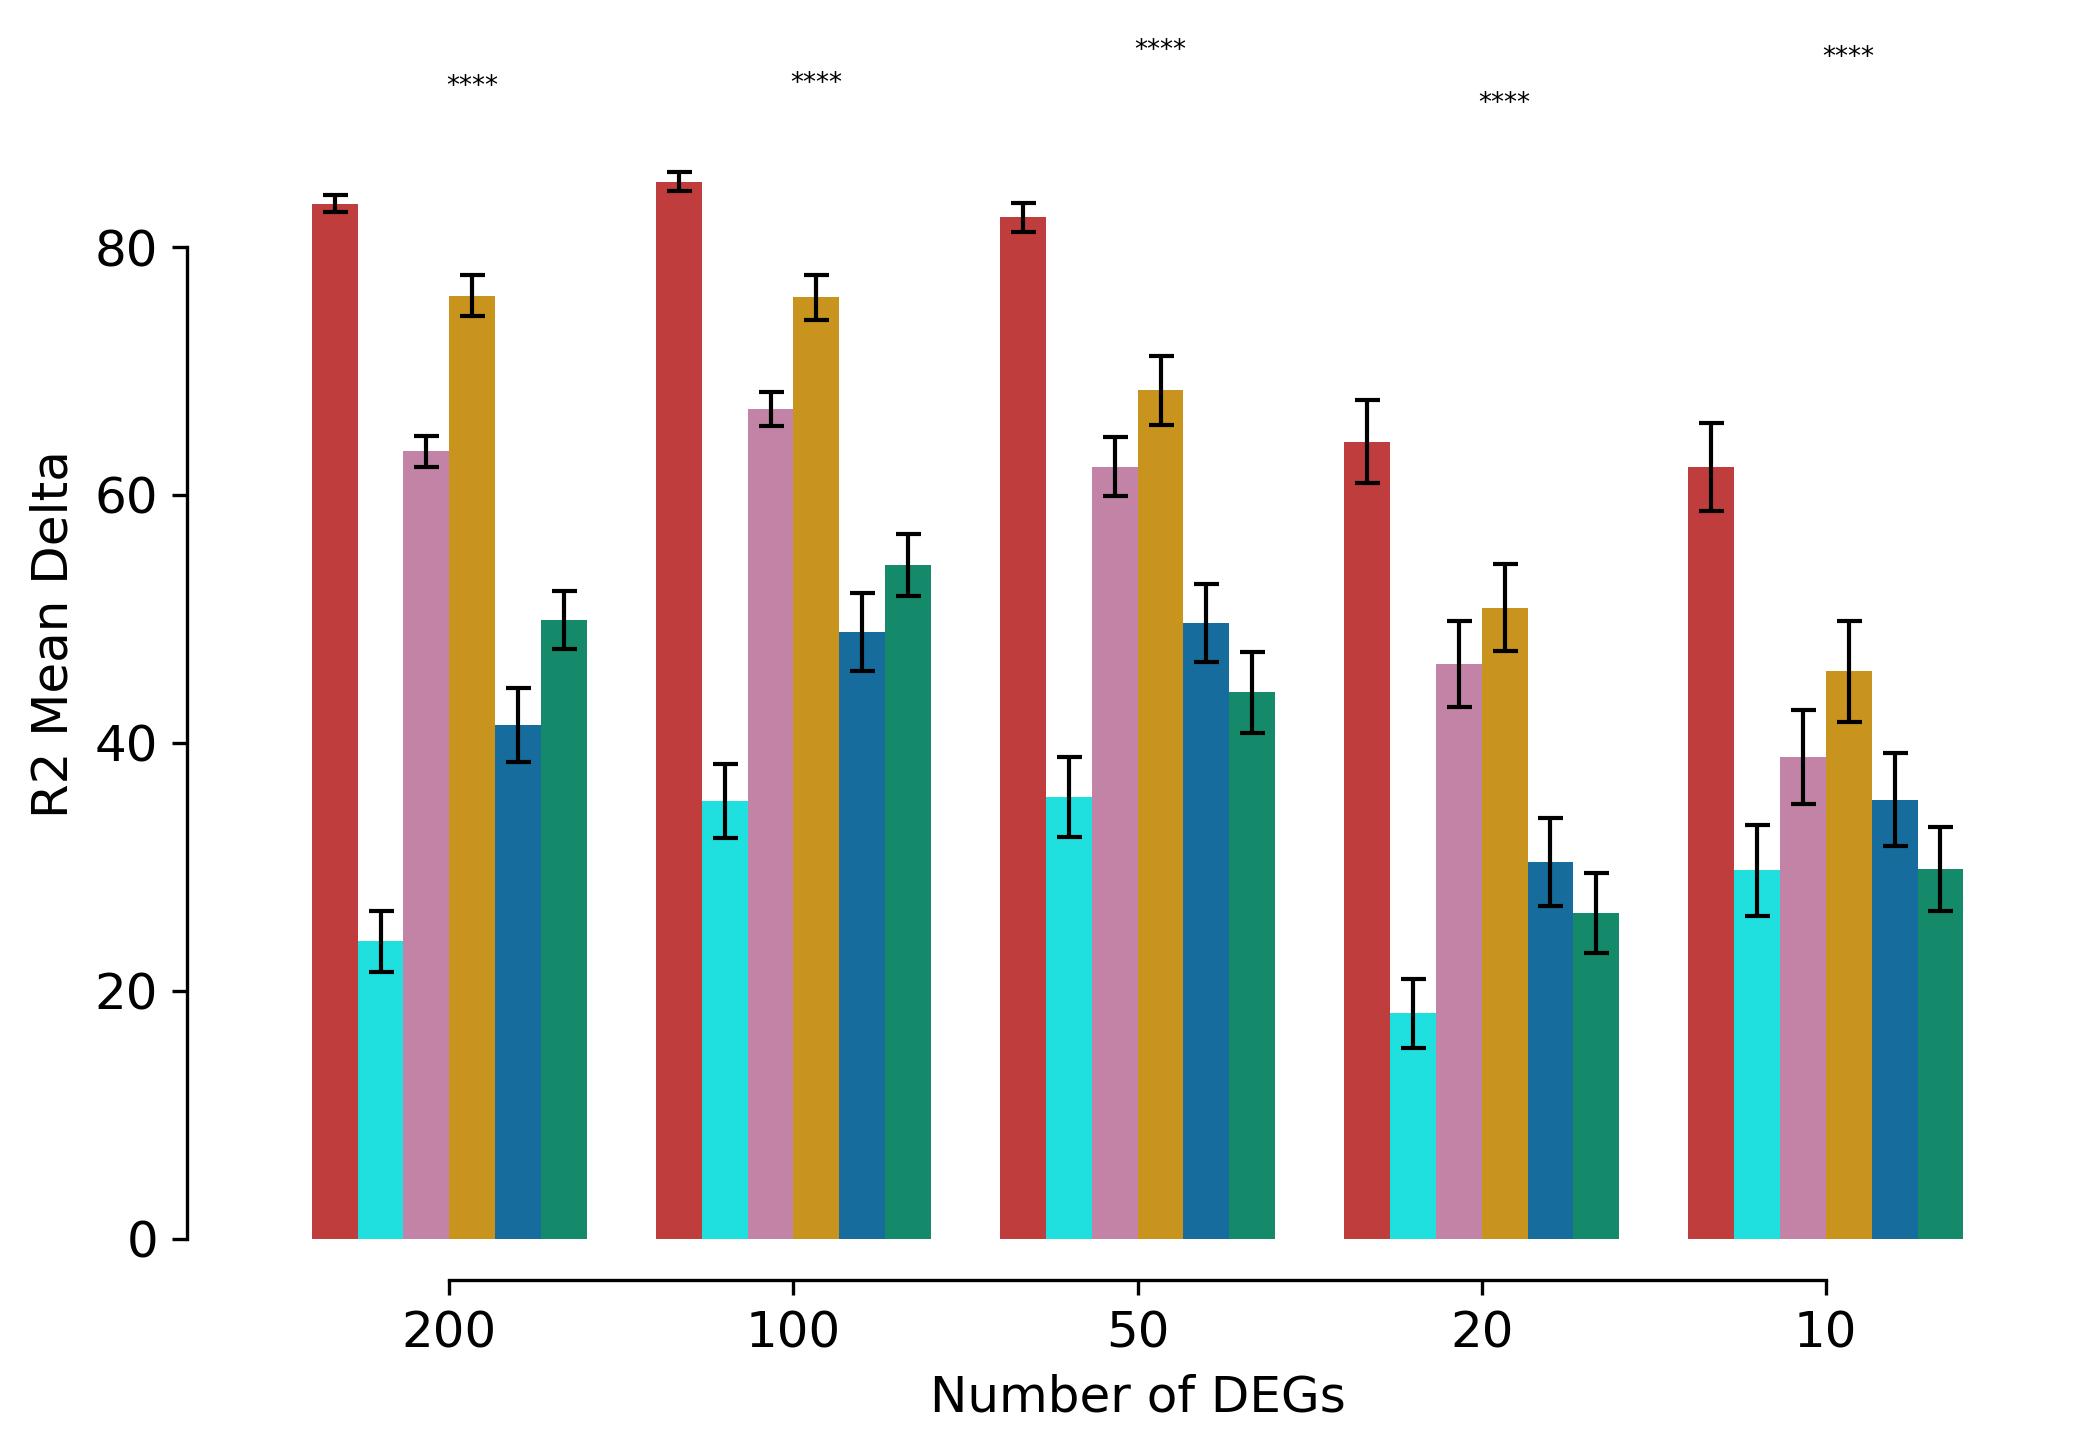

Using 80 perturbation


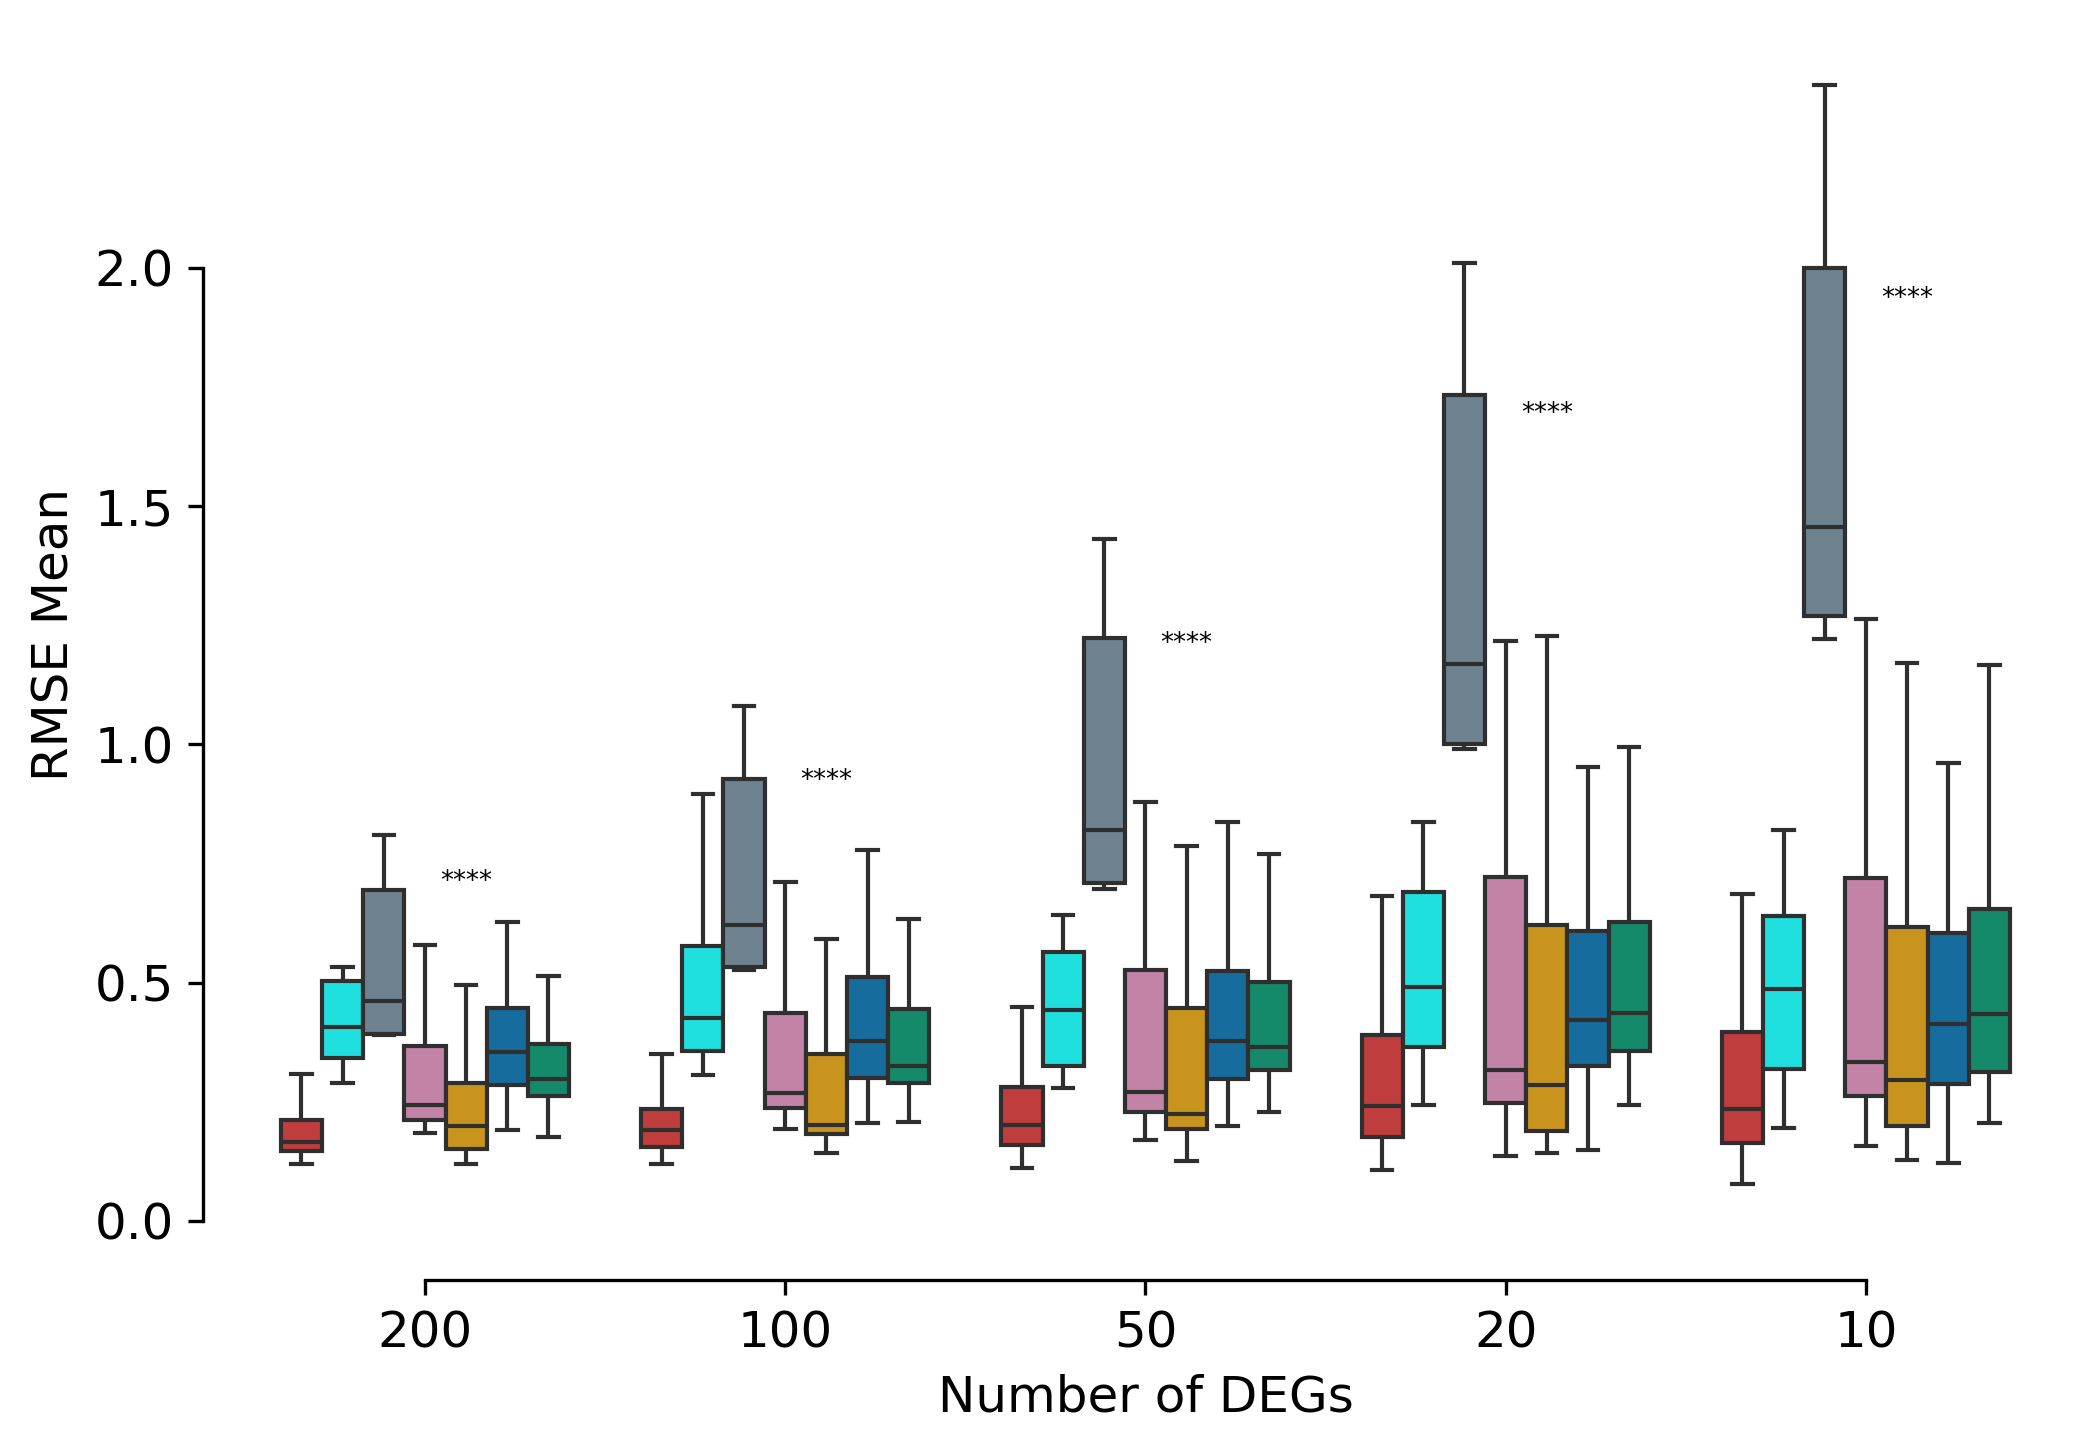

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


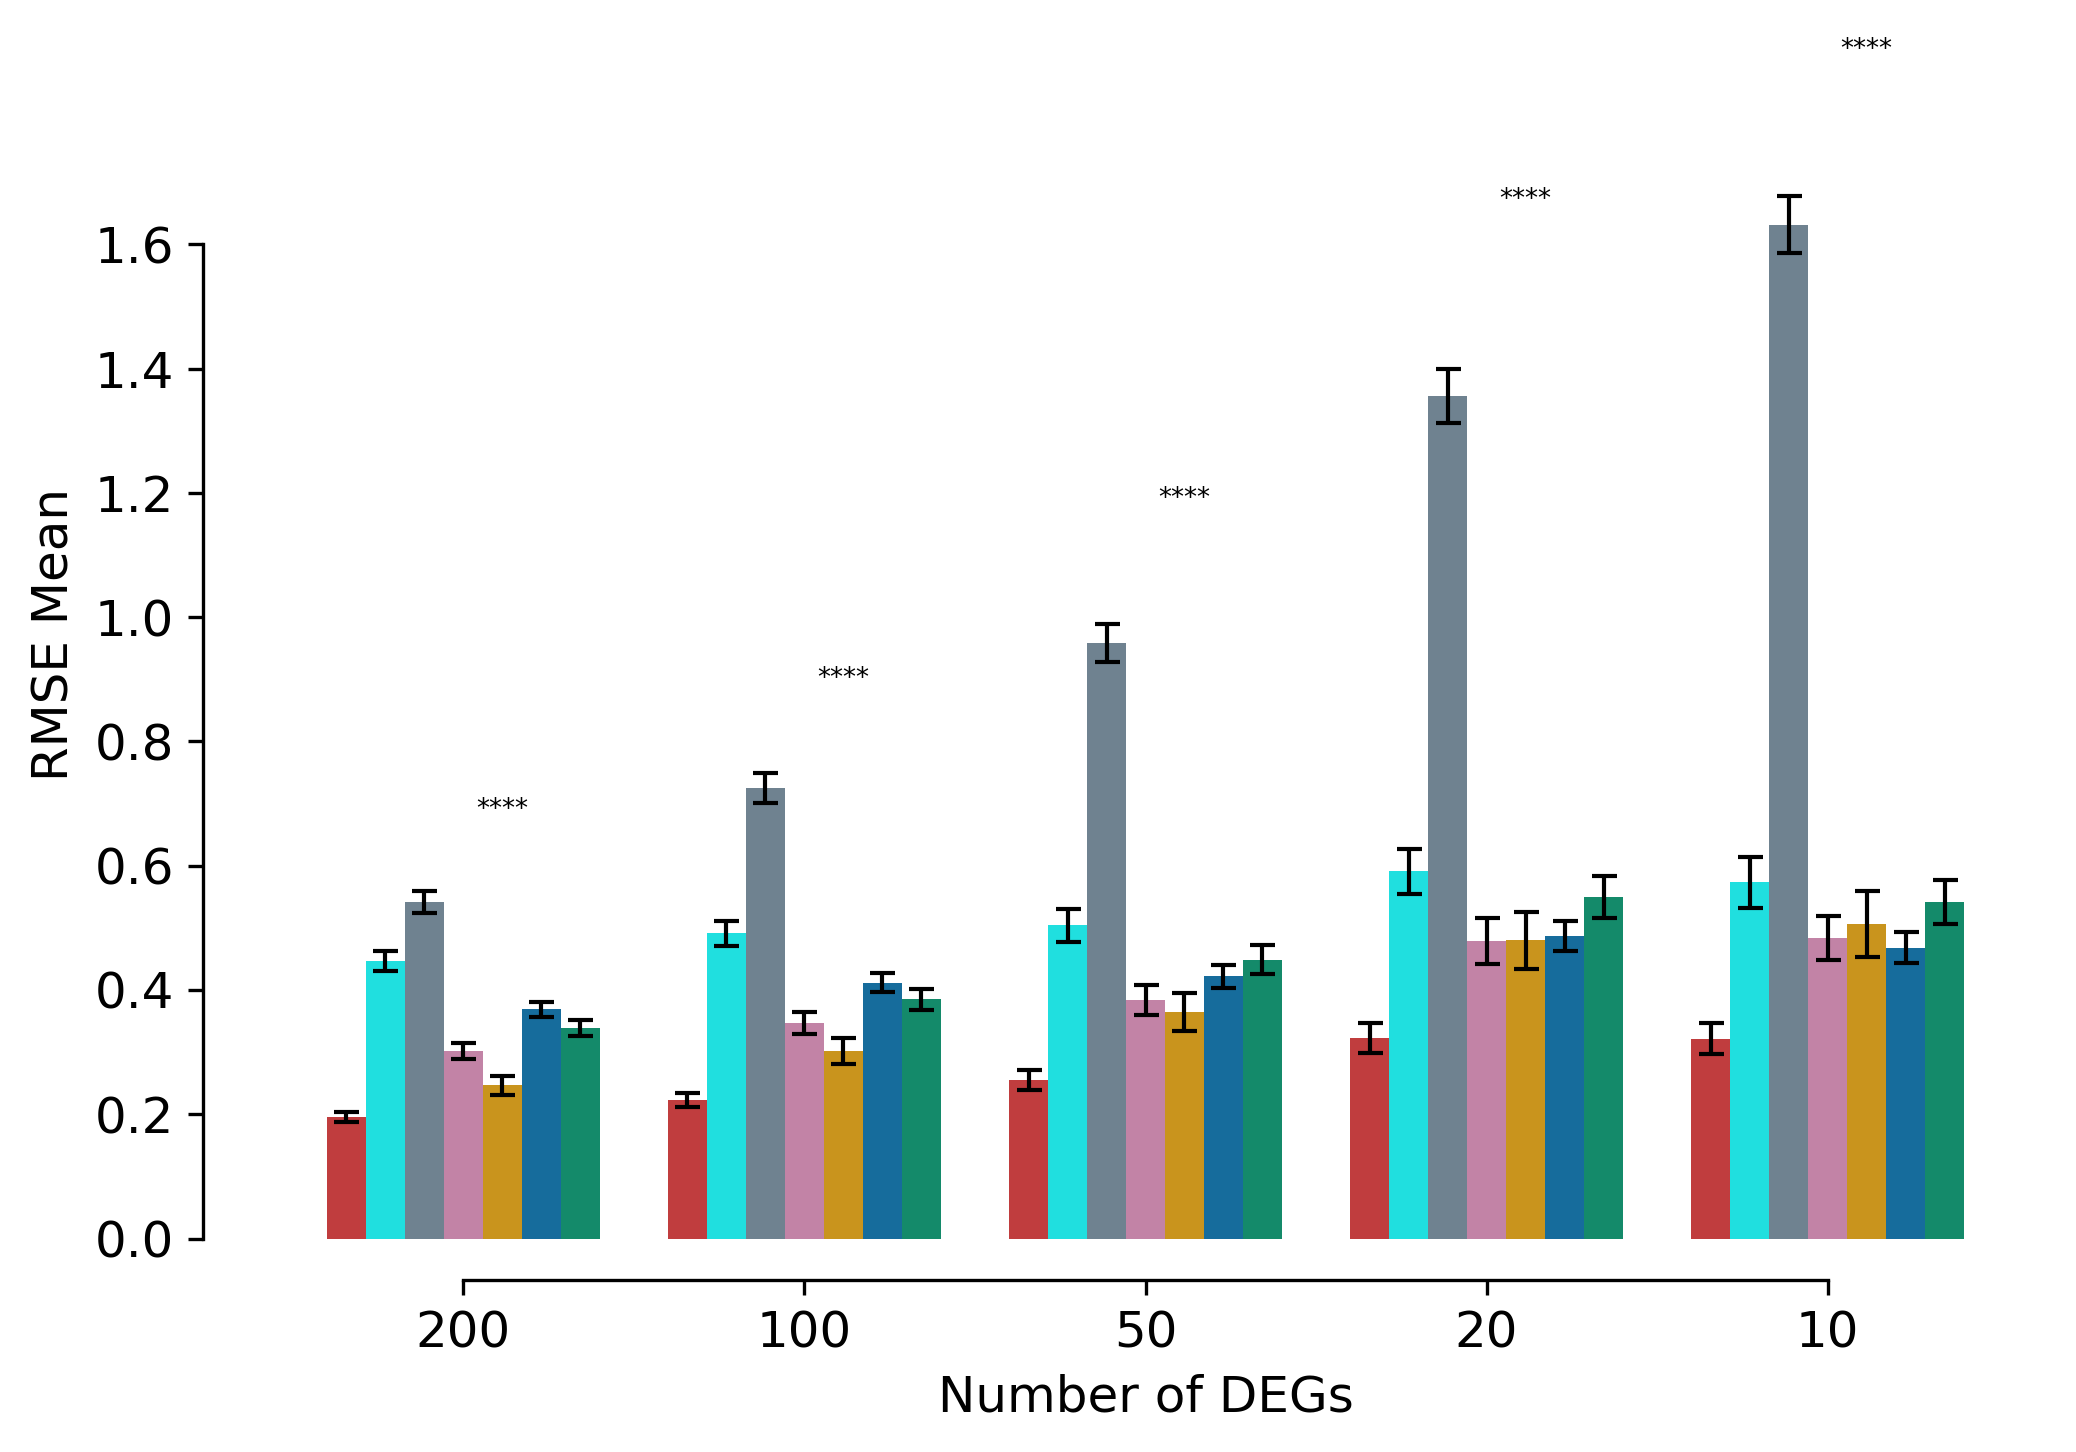

Using 80 perturbation


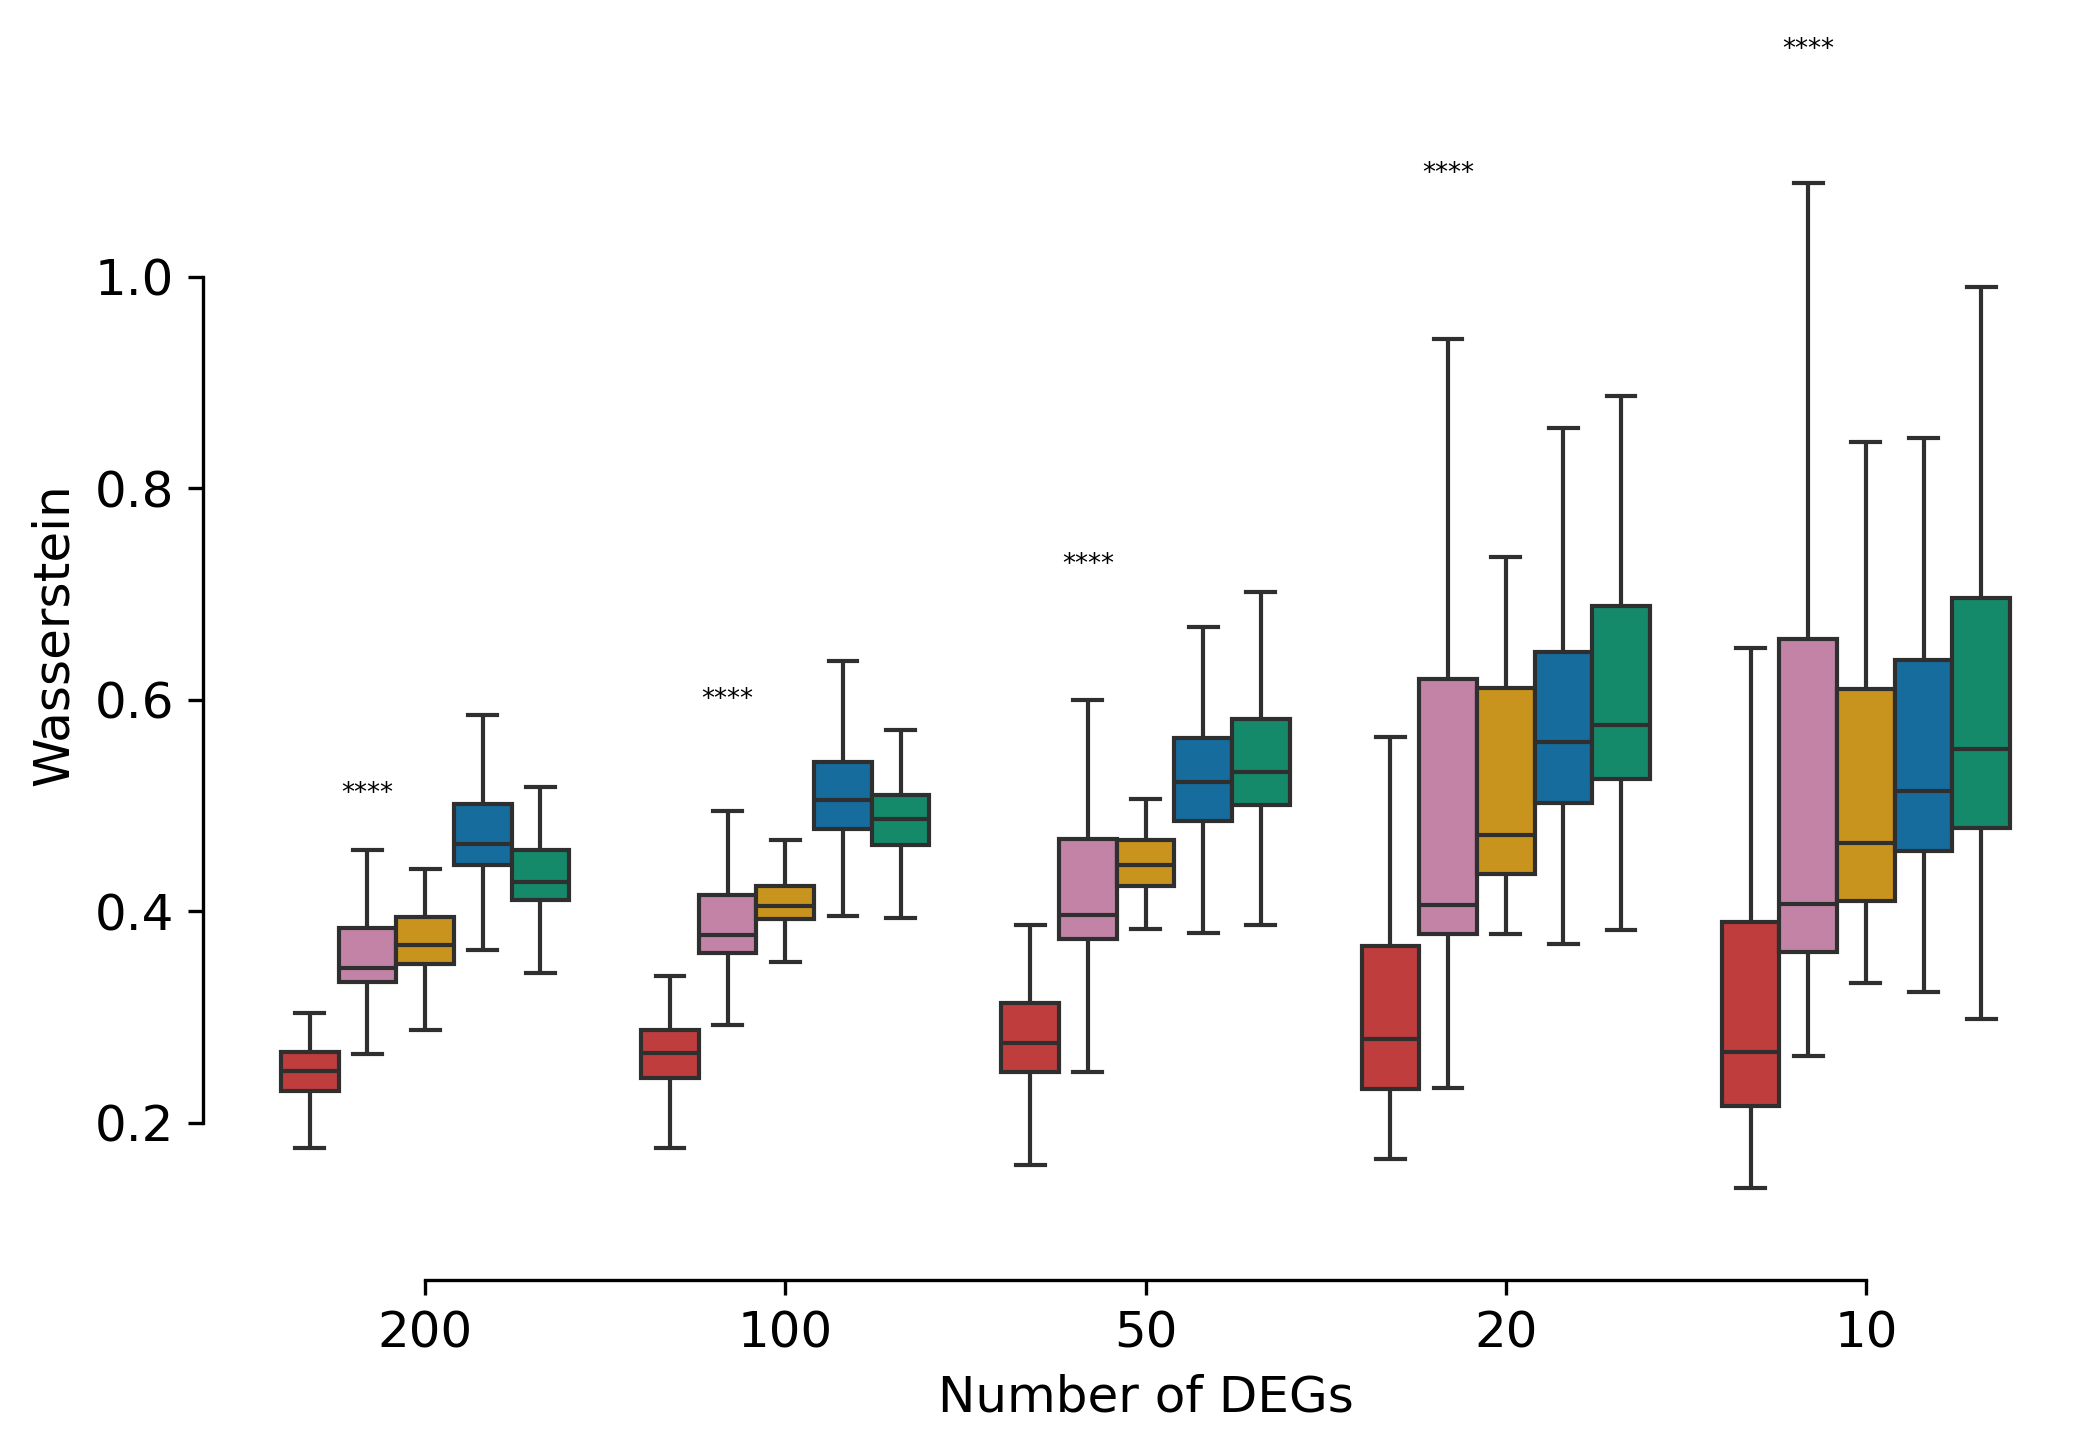

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


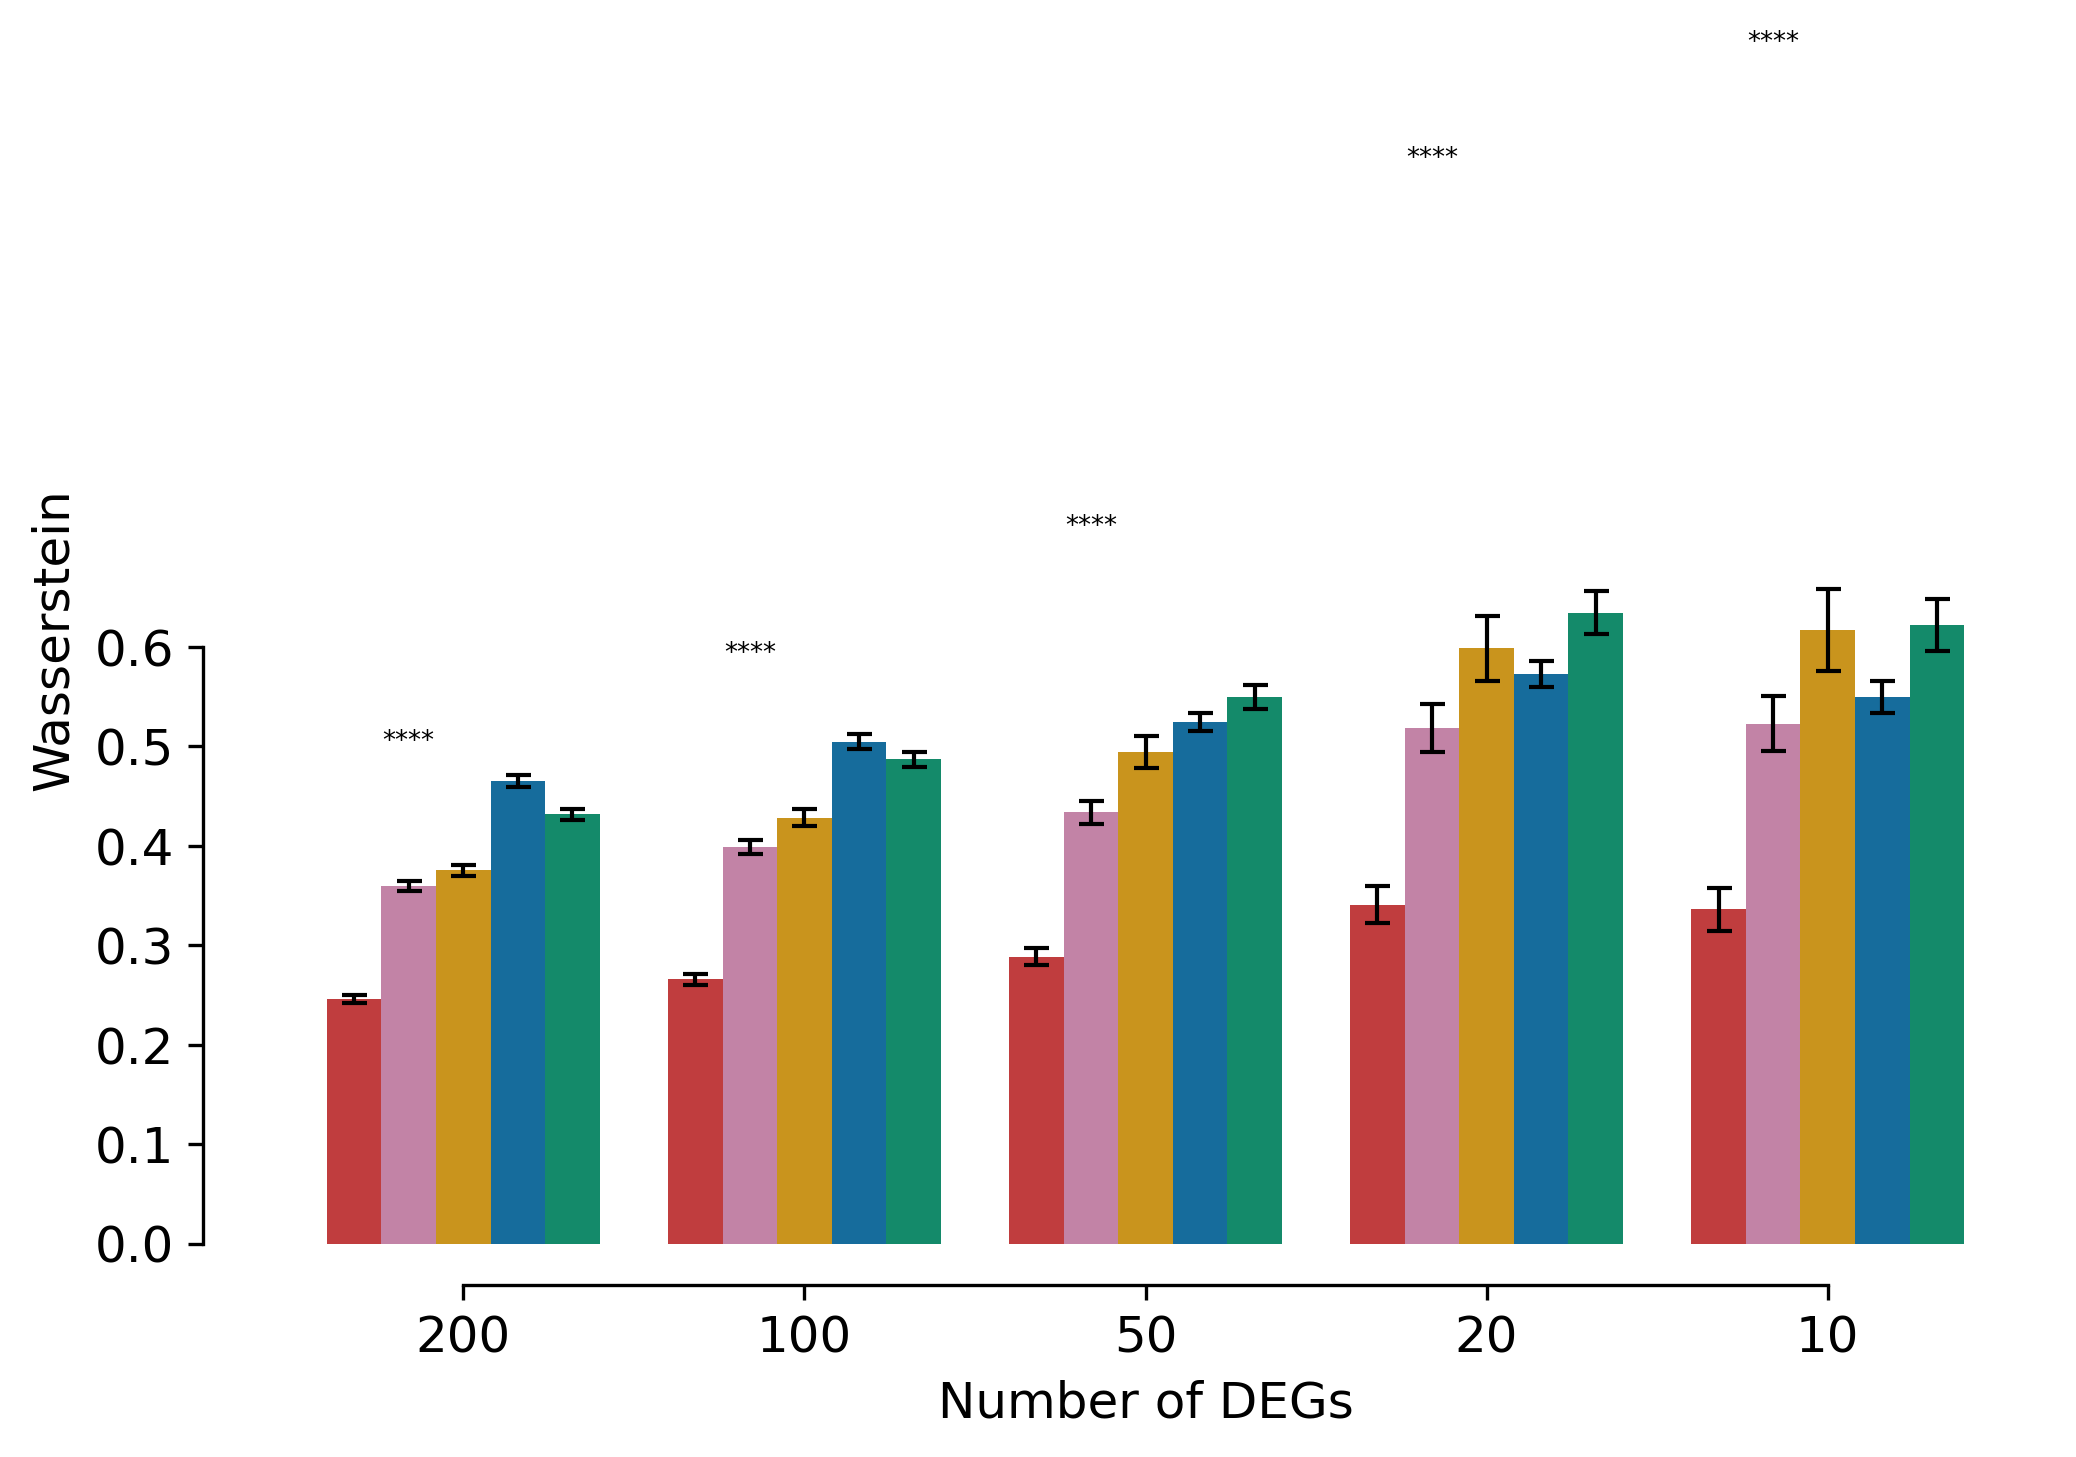

Using 80 perturbation


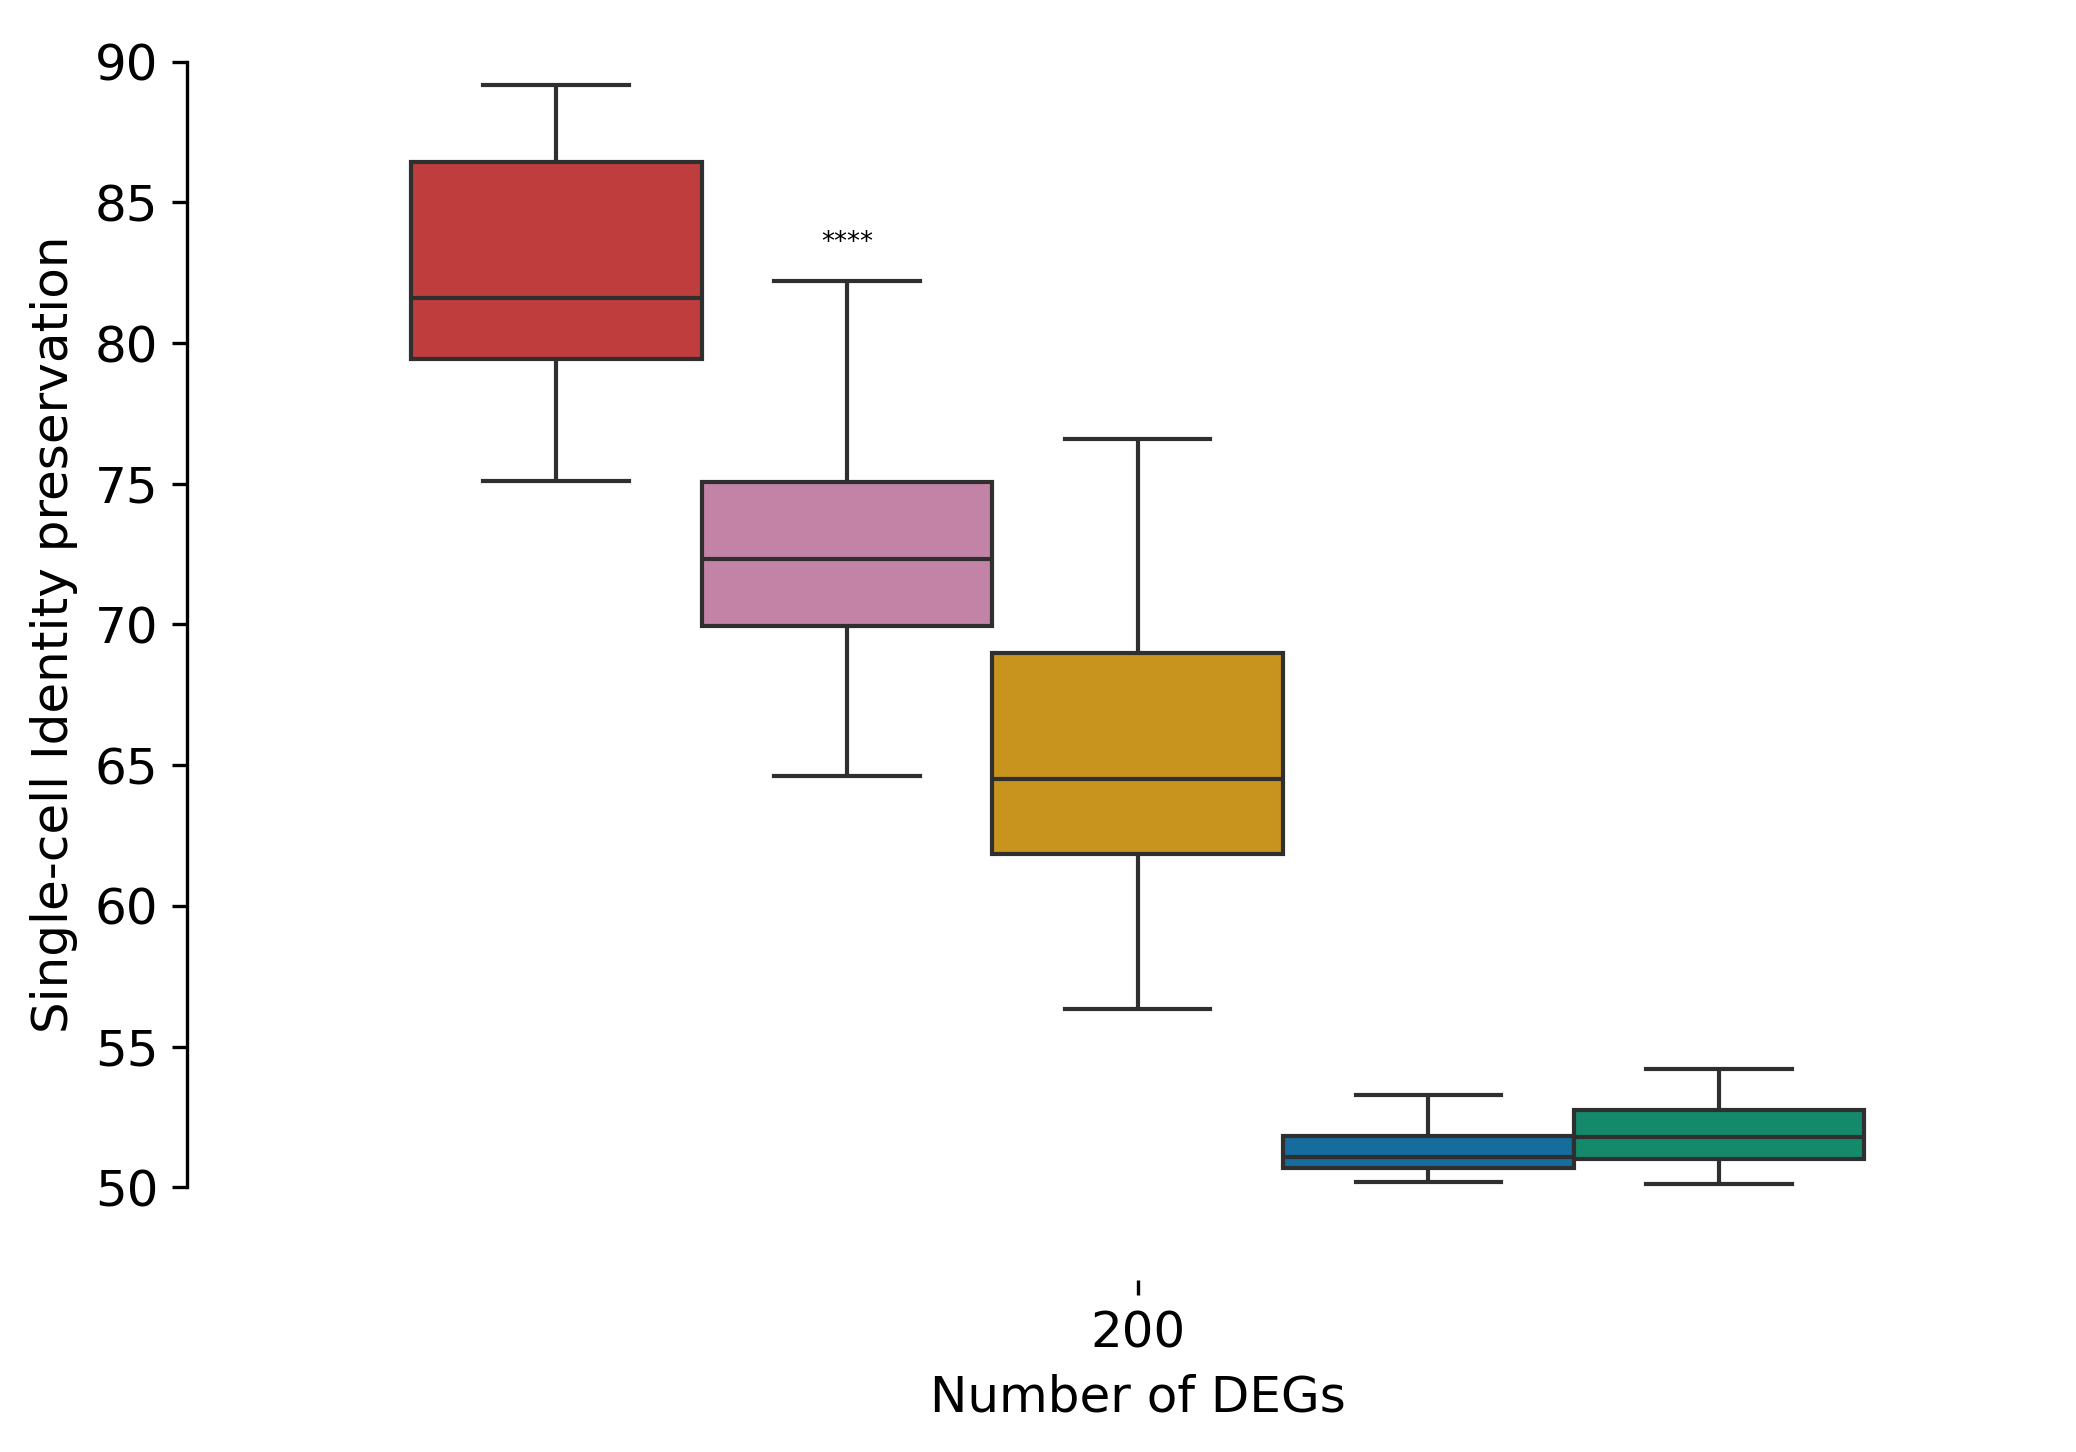

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


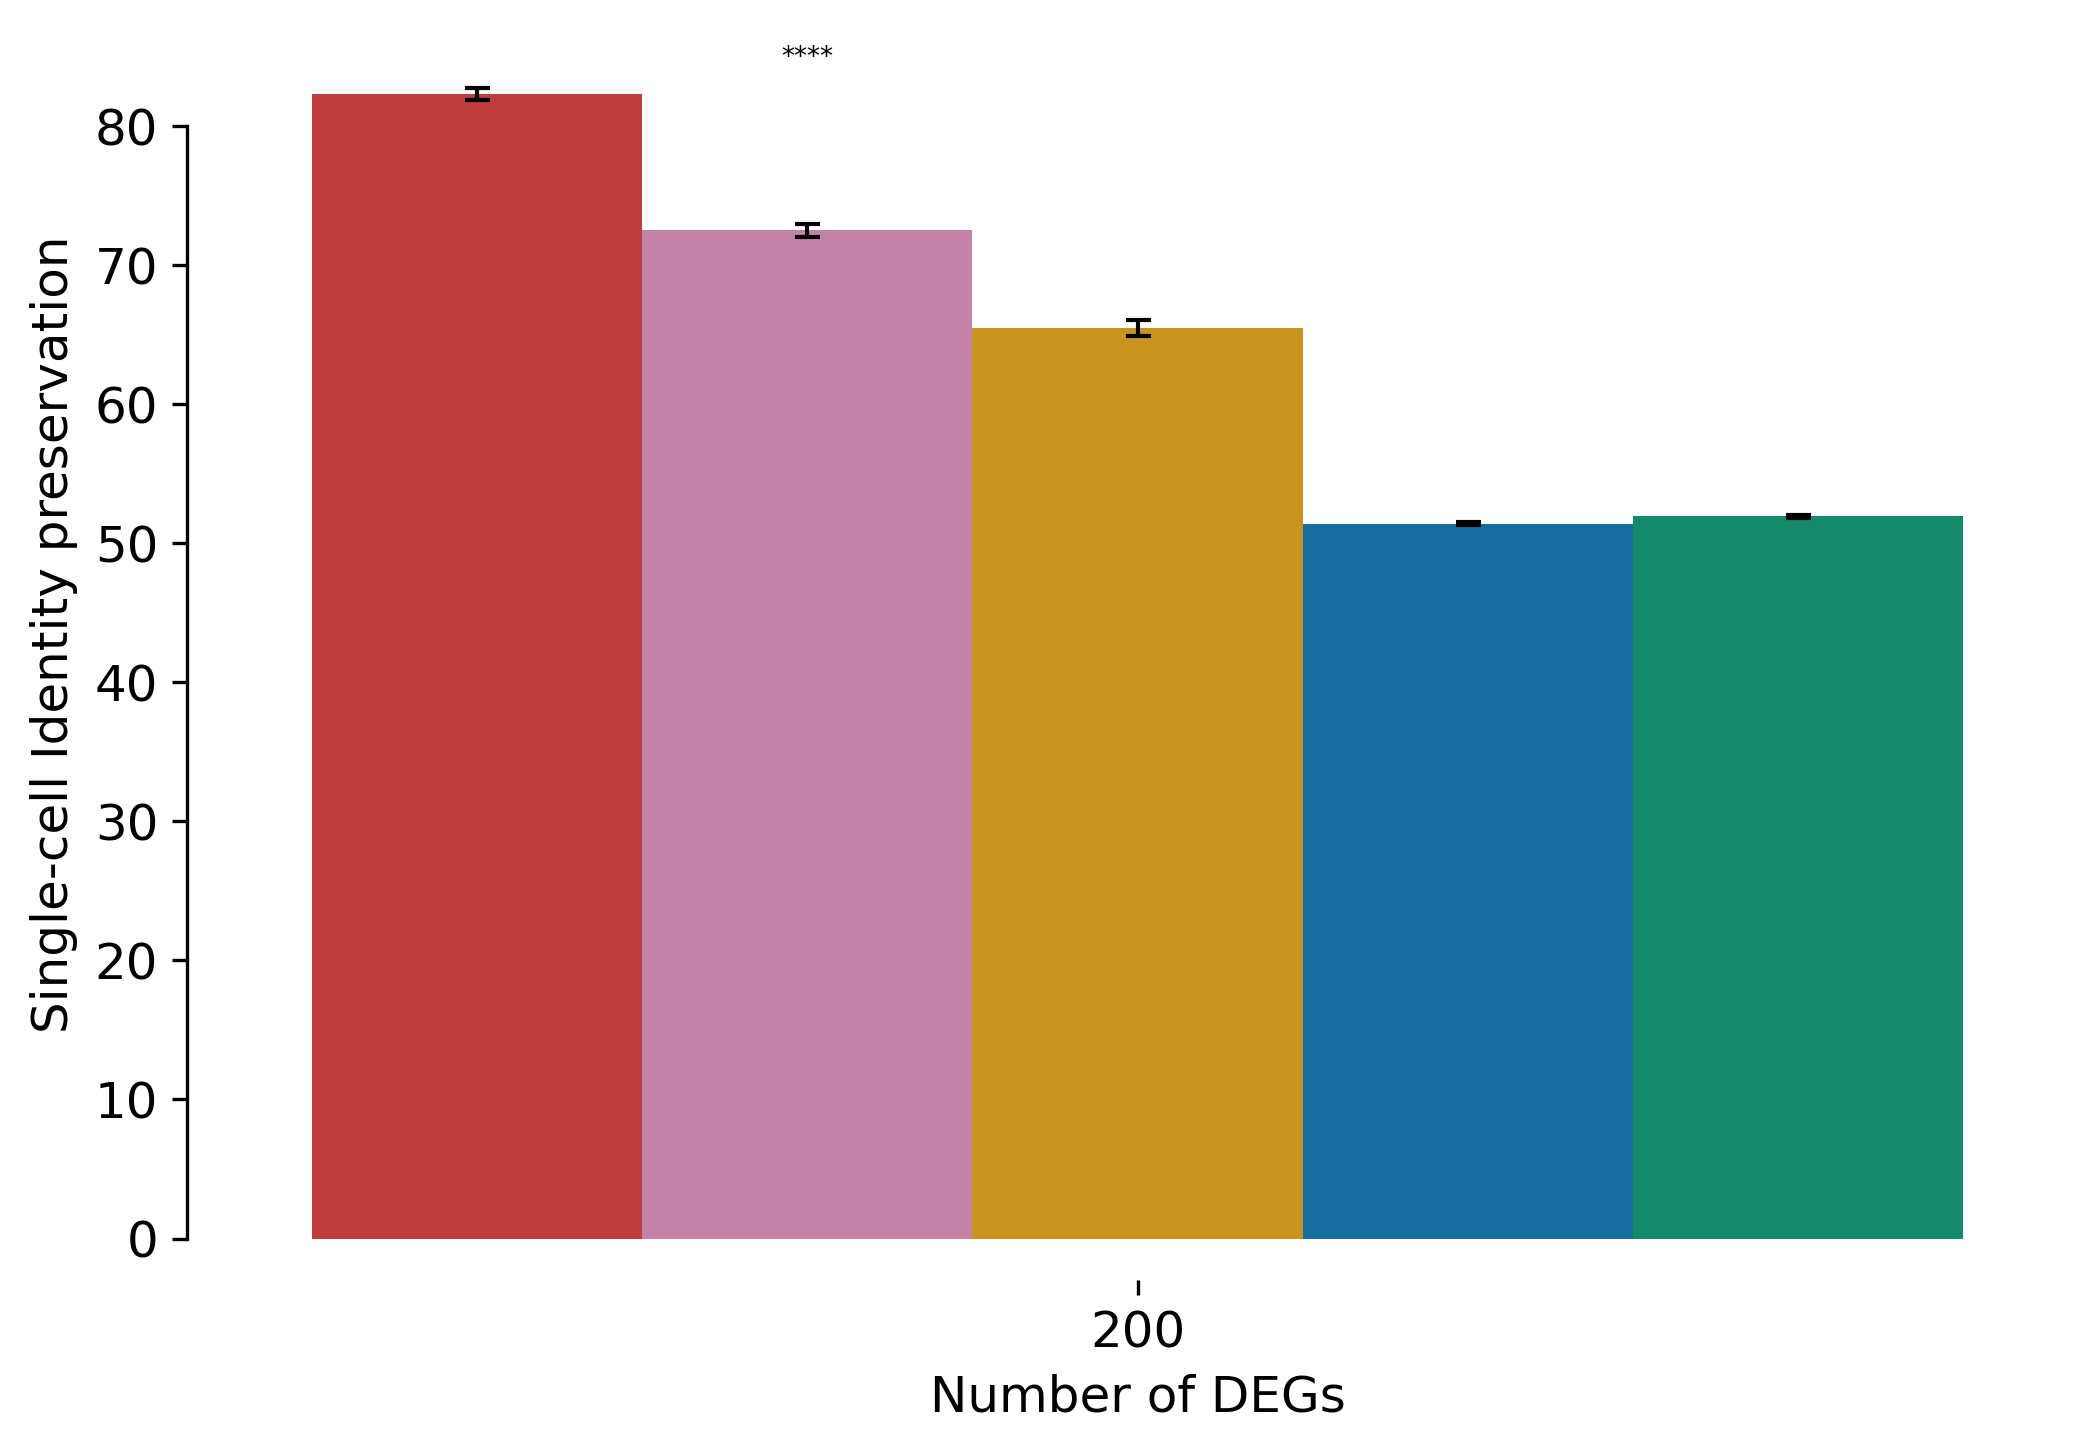

Using 80 perturbation


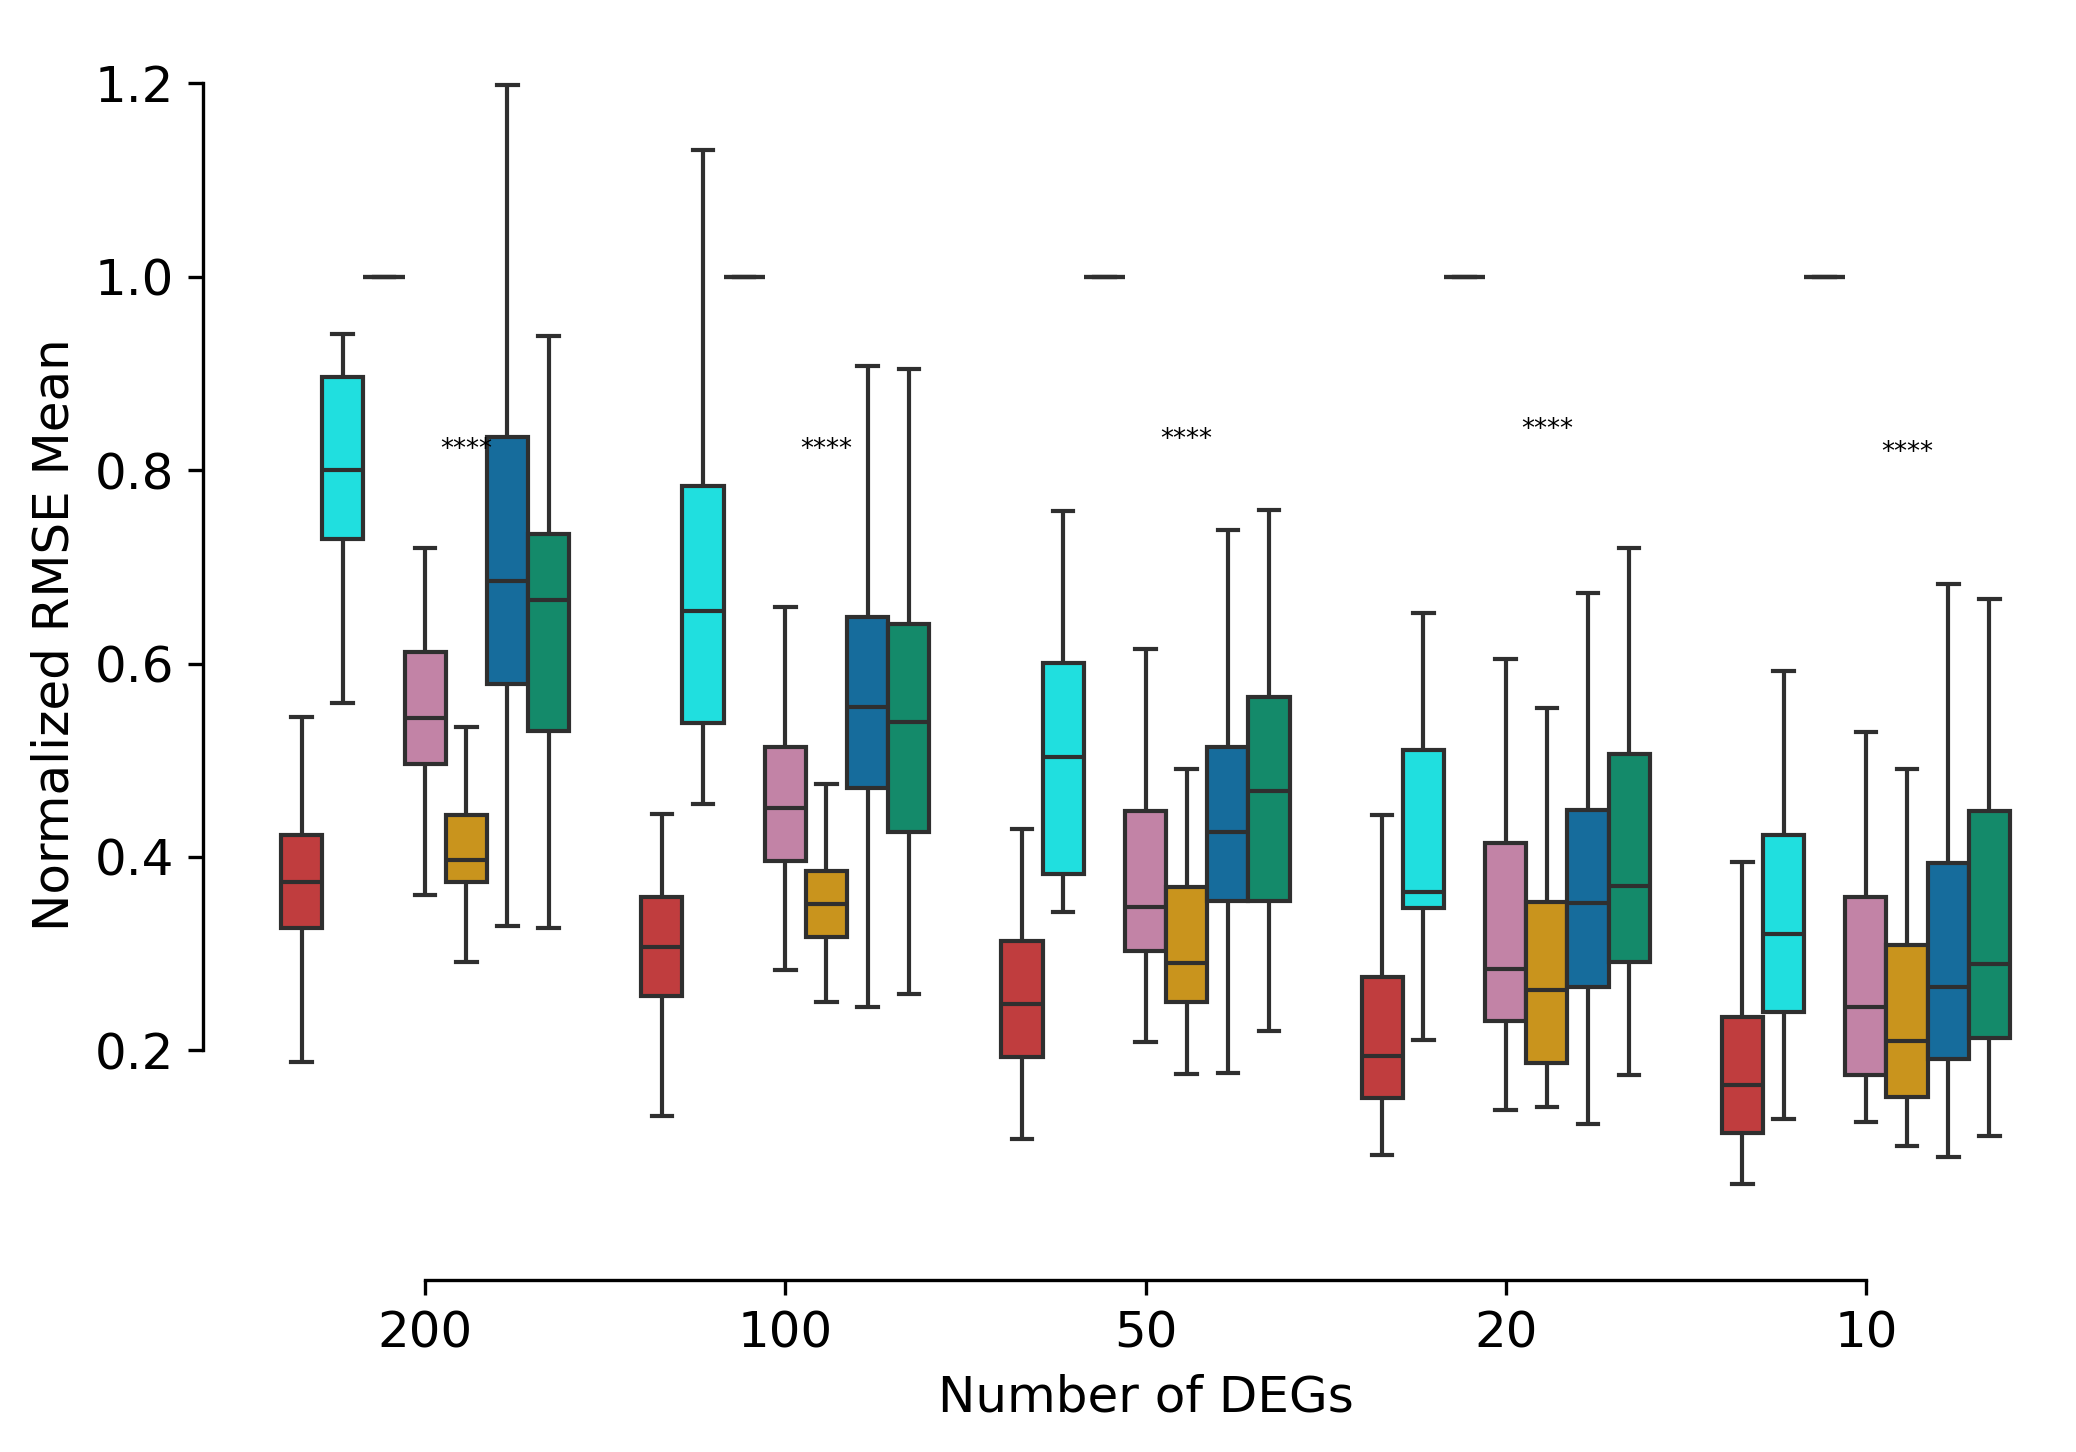

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


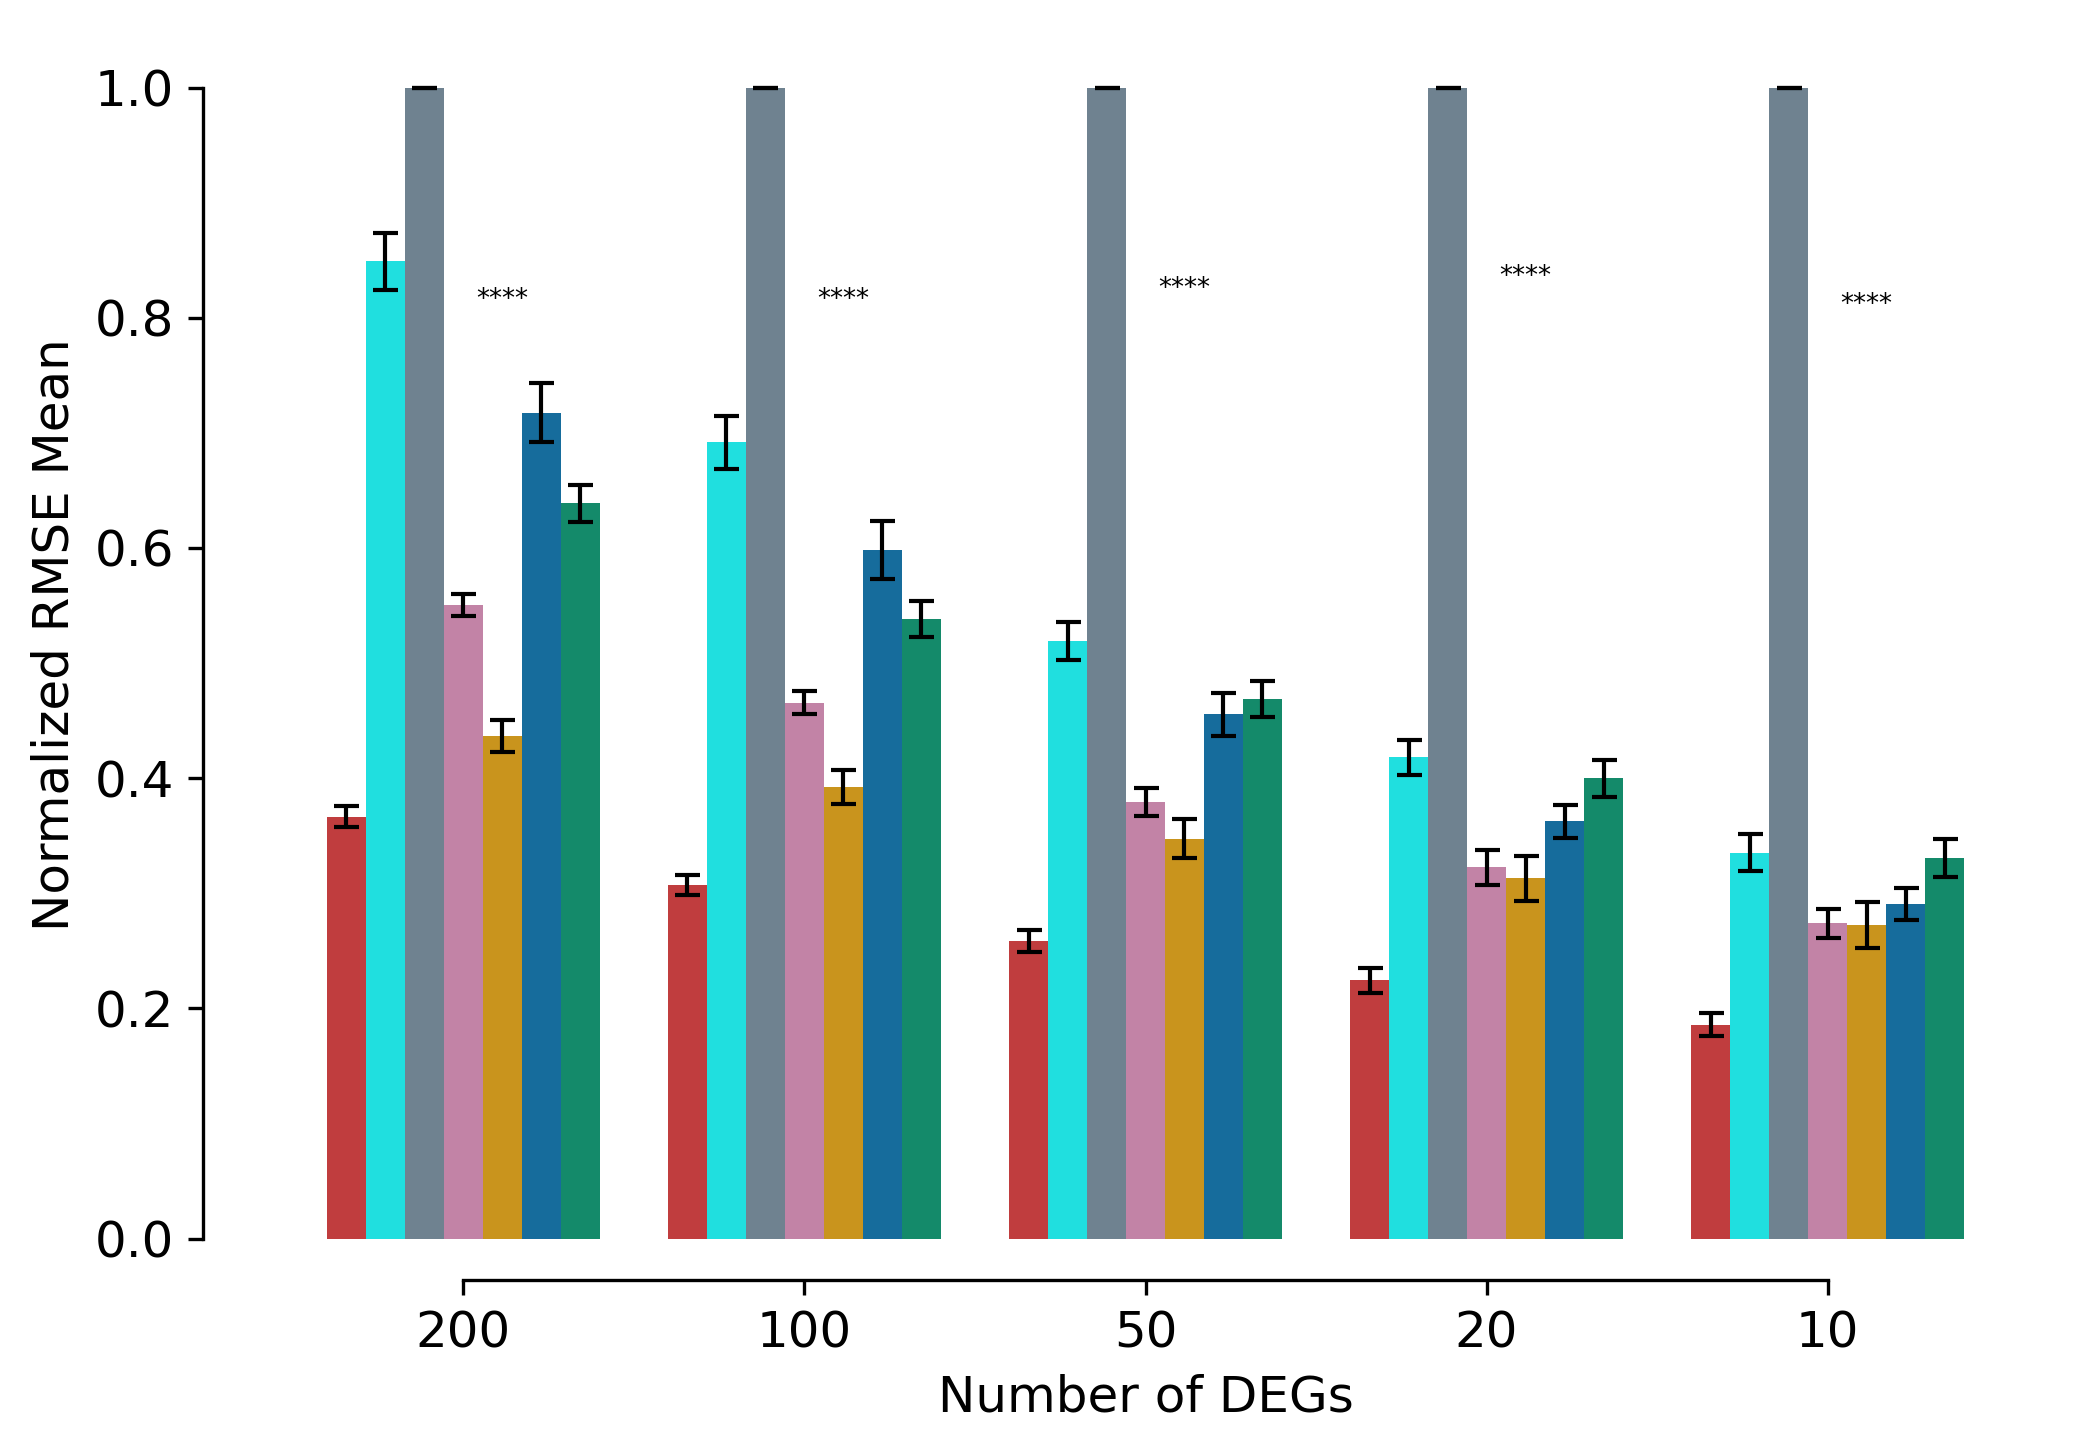

In [7]:
_colors = {
    'scDisentangle': '#d62728',
    'Context-agnostic': '#00FFFF', #'#698396',
    'Perturbation-agnostic': '#698396', #'#00FFFF',
    'CPA': '#CC79A7',
    'scGEN': '#E69F00',
    'ScDisInFact': '#0072B2',
    'Biolord': '#009E73',
    
    }

_folder_paths = {
     'scDisentangle': f'{base_path}/SCDISENTANGLE/',
     'Context-agnostic': f'{base_path}/Pert Mean',
     'Perturbation-agnostic': f'{base_path}/Ctrl Mean',
     'ScDisInFact': f'{base_path}/SCDISINFACT/',
     'CPA': f'{base_path}/CPA/',
     'scGEN': f'{base_path}/SCGEN/',
     'Biolord': f'{base_path}/BIOLORD/',      
}

for metric_name in [
    'R2 Mean', 'Pearson Mean Delta', 
    'R2 Mean Delta', 'RMSE Mean', 'Wasserstein',
    'Single-cell Identity preservation',
    'Normalized RMSE Mean'
]:
    if metric_name == 'Single-cell Identity preservation':
        n_degs_list = ['200']
    else:
        n_degs_list = ['200', '100', '50', '20', '10']
        
   

    if metric_name not in ['R2 Mean', 'Pearson Mean', 'Pearson Mean Delta', 'R2 Mean Delta', 'RMSE Mean', 'Normalized RMSE Mean']:
        colors = {k:v for k,v in _colors.items() if not k in ['Perturbation-agnostic', 'Context-agnostic']}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k in ['Perturbation-agnostic', 'Context-agnostic']}
    
    elif 'Delta' in metric_name:
        colors = {k:v for k,v in _colors.items() if not k == 'Perturbation-agnostic'}
        folder_paths = {k:v for k,v in _folder_paths.items() if not k == 'Perturbation-agnostic'}
        
    else:
        colors = _colors
        folder_paths = _folder_paths
        
    metrics = mt.get_results(
        folder_paths, 
        metric_name=metric_name, 
        perts = all_results, 
        n_degs_list=n_degs_list
    )
    
    pvals, stars = mt.compute_pvalues_by_context(
        metrics_dict=metrics,
        metric_name=metric_name,
        run_ids=all_results,
        higher_is_better=None,
        anchor='scDisentangle'
    )
    
    records = hp.plot_data(
                metrics,
                plot_type='boxplot', 
                save_path=f'{FIG_ROOT}/{data_name}/Benchmarks/{metric_name}_box',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars
            )
    
    records = hp.plot_data(
                metrics,
                plot_type='barplot', 
                save_path=f'{FIG_ROOT}/{data_name}/Benchmarks/{metric_name}_bar',
                y_name=metric_name, 
                legend=False, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars
            )

/data/REPRODUCE_REPOS/scdisentangle_reproducibility/package/hygeia/hygeia/utils/hplots.py:208: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


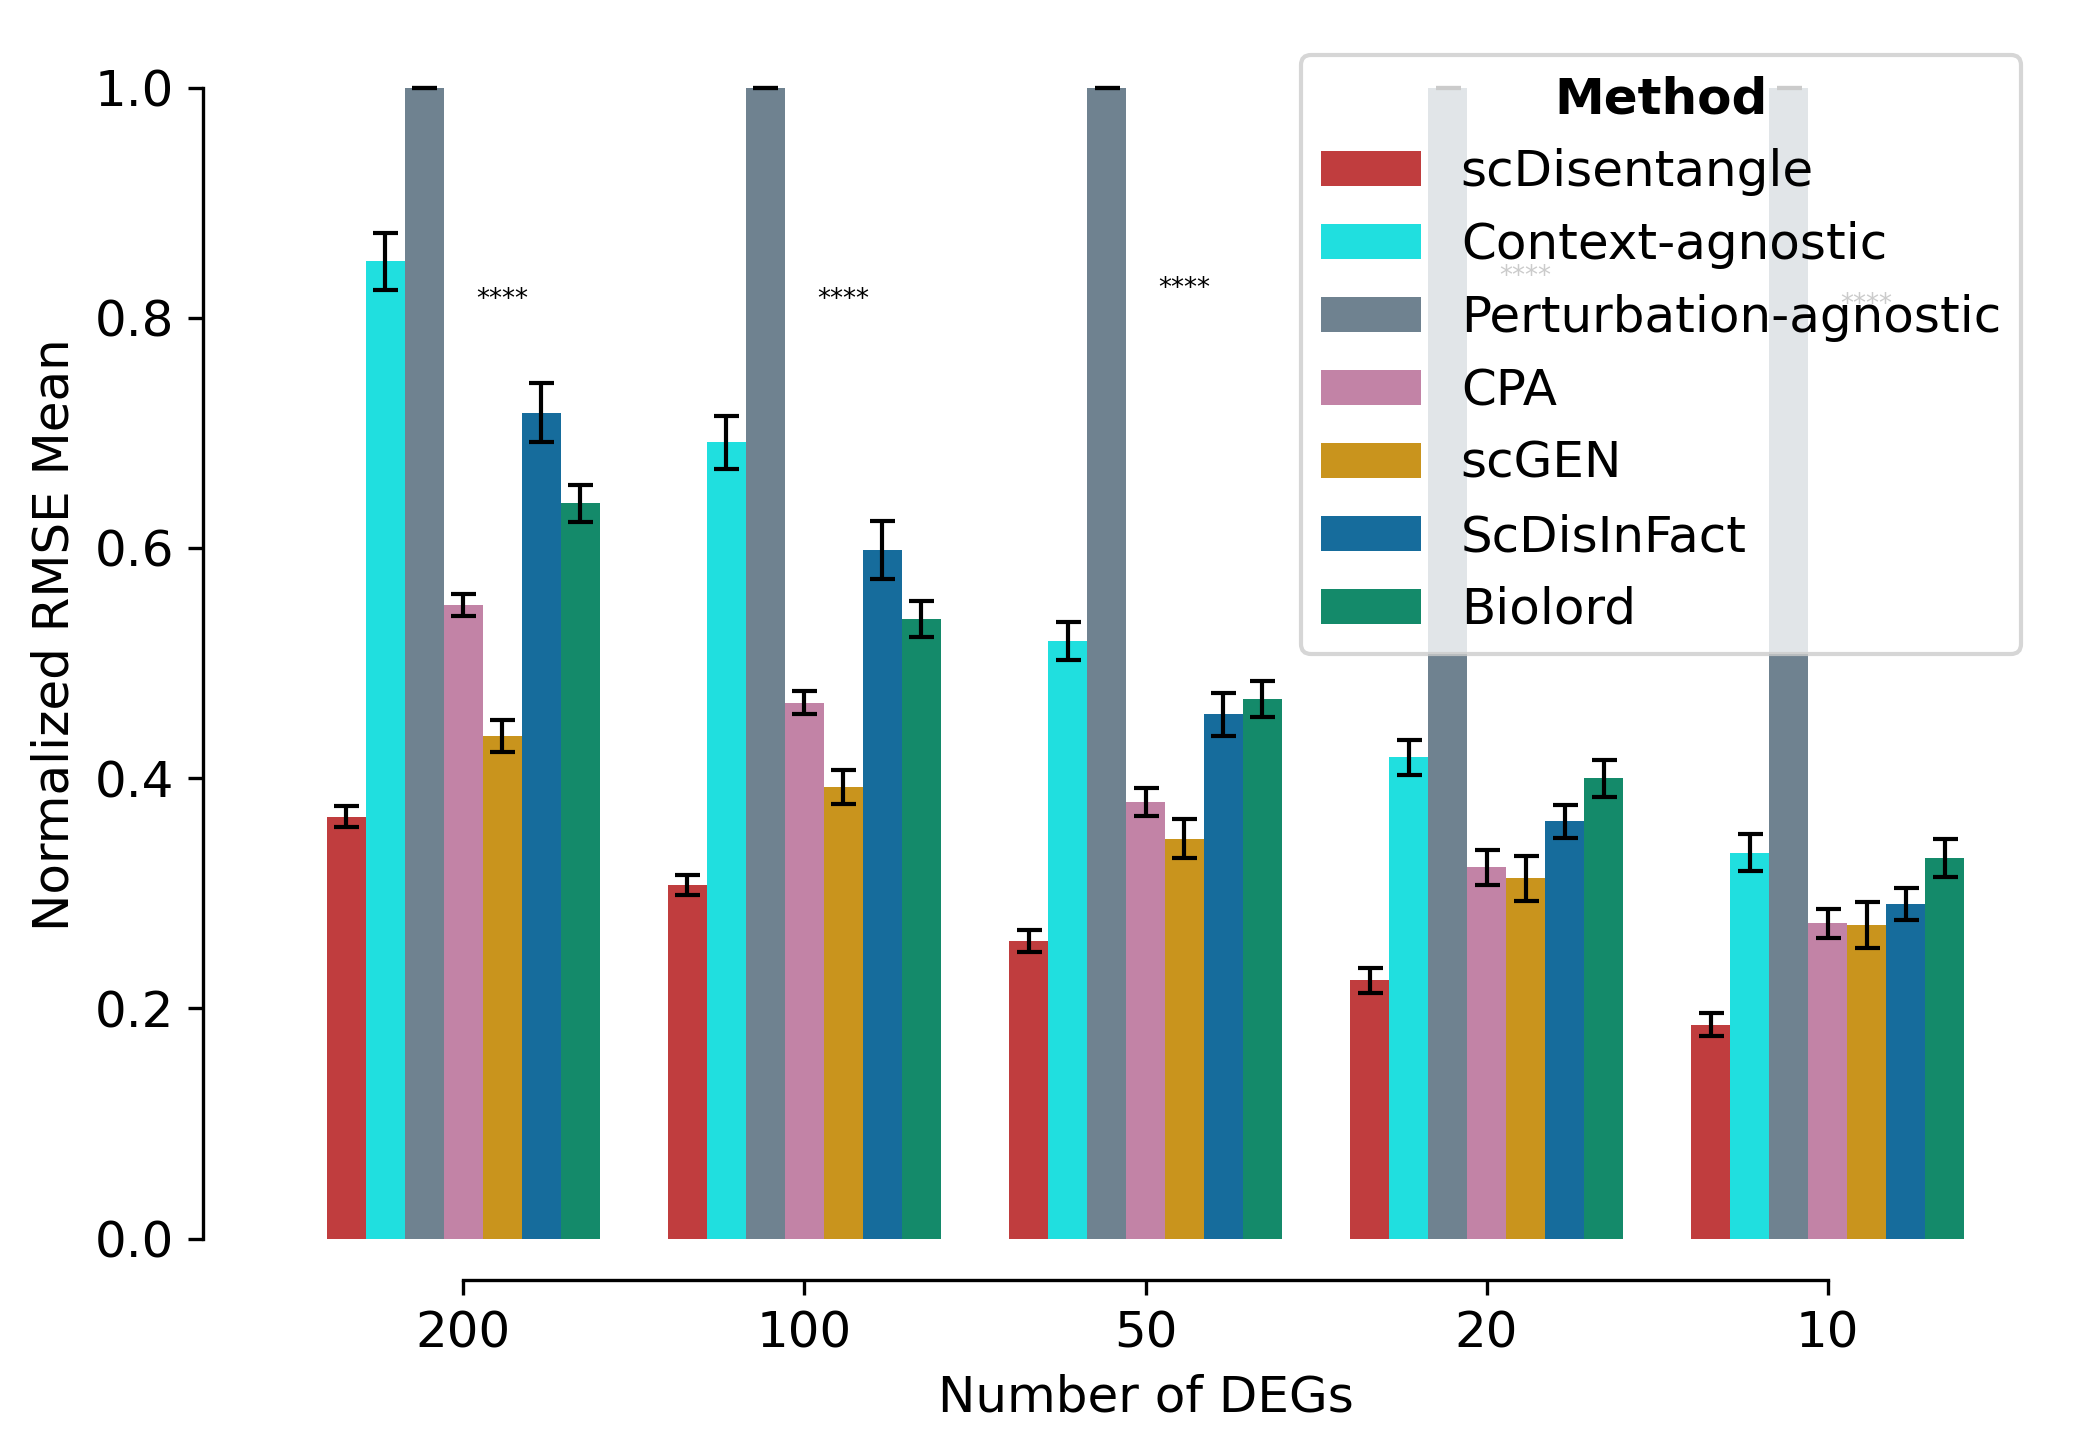

In [8]:
records = hp.plot_data(
                metrics,
                plot_type='barplot', 
                save_path=f'{FIG_ROOT}/{data_name}/LEGENDS',
                y_name=metric_name, 
                legend=True, 
                title='',
                colors=colors,
                show_grid=False,
                sort_order=None,
                stars=stars
            )